# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Adetya Tino Forrestiawan
- Email: adetyatino@gmail.com
- Id Dicoding: adetya_tino

## 1. Persiapan

### 1.1 Menyiapkan library yang dibutuhkan

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm  
import numpy as np
import re
import joblib
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report 
from sklearn.model_selection import GridSearchCV 
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Pengaturan visualisasi
%matplotlib inline
sns.set(style="whitegrid")



#### 1.2 Menyiapkan data yang akan diguankan

In [2]:
# Memuat dataset
# Dataset import from Dicoding GitHub Repository
dataset_url = 'https://github.com/dicodingacademy/dicoding_dataset/blob/bce7a57a496d083716138922bc5839b5c30fa4ea/employee/employee_data.csv?raw=true'

# Read dataset
df = pd.read_csv(dataset_url)

# Preprocessing awal: Mengisi missing value pada Attrition dan membuat label status
df['Attrition'] = df['Attrition'].fillna(0)
df['Attrition_Status'] = df['Attrition'].apply(lambda x: 'Resigned' if x == 1 else 'Active')

df.head()

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition_Status
0,1,38,0.0,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,80,1,7,2,3,6,2,1,2,Active
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,80,0,15,2,1,1,0,0,0,Resigned
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,80,3,18,2,4,10,0,2,7,Resigned
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,80,1,23,2,4,20,4,4,8,Active
4,5,40,0.0,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,80,3,20,2,3,5,3,0,2,Active


In [3]:
dataset_url = 'https://github.com/dicodingacademy/dicoding_dataset/blob/bce7a57a496d083716138922bc5839b5c30fa4ea/employee/README.md?raw=true'

#### 1.3 Data Preparation

##### 1.3.1 Data Summary

In [4]:
# Informasi dasar dataset
print("Informasi Dataset:")
df.info()

# Deskripsi statistik
print("\nStatistik Deskriptif (Numeric):")
display(df.describe())

# Mengecek nilai Attrition Rate secara keseluruhan
total_emp = len(df)
attrition_count = df['Attrition'].sum()
attrition_rate = (attrition_count / total_emp) * 100
print(f"\nTotal Karyawan: {total_emp}")
print(f"Total Attrition: {attrition_count}")
print(f"Overall Attrition Rate: {attrition_rate:.2f}%")

Informasi Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1470 non-null   float64
 3   BusinessTravel            1470 non-null   str    
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   str    
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   str    
 9   EmployeeCount             1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   str    
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   int64  
 14  

,EmployeeId,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,735.500000,36.923810,0.121769,802.485714,9.192517,2.912925,1.0,2.721769,65.891156,2.729932,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,424.496761,9.135373,0.327130,403.509100,8.106864,1.024165,0.0,1.093082,20.329428,0.711561,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,1.000000,18.000000,0.000000,102.000000,1.000000,1.000000,1.0,1.000000,30.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,368.250000,30.000000,0.000000,465.000000,2.000000,2.000000,1.0,2.000000,48.000000,2.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,735.500000,36.000000,0.000000,802.000000,7.000000,3.000000,1.0,3.000000,66.000000,3.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,1102.750000,43.000000,0.000000,1157.000000,14.000000,4.000000,1.0,4.000000,83.750000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,1470.000000,60.000000,1.000000,1499.000000,29.000000,5.000000,1.0,4.000000,100.000000,4.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000



Total Karyawan: 1470
Total Attrition: 179.0
Overall Attrition Rate: 12.18%


##### 1.3.2 Menyiapkan data untuk Machine Learning (Feature Importance)

In [5]:
df_ml = df.copy()
le = LabelEncoder()

# Encoding kolom kategori
for col in df_ml.select_dtypes(include=['object']).columns:
    if col != 'Attrition_Status':
        df_ml[col] = le.fit_transform(df_ml[col].astype(str))

# Fitur (X) dan target (y)
# Menghapus kolom yang tidak relevan secara statistik
drop_cols = ['Attrition', 'Attrition_Status', 'EmployeeId', 'EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
X = df_ml.drop([c for c in drop_cols if c in df_ml.columns], axis=1)
y = df_ml['Attrition']

print("Fitur yang digunakan untuk modeling:")
print(X.columns.tolist())

Fitur yang digunakan untuk modeling:
['Age', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


C:\Users\adety.AdetyaTino\AppData\Local\Temp\ipykernel_12304\3545640142.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_ml.select_dtypes(include=['object']).columns:


## 2. Data Understanding

##### 2.1 Peta Metrik Korelasi 

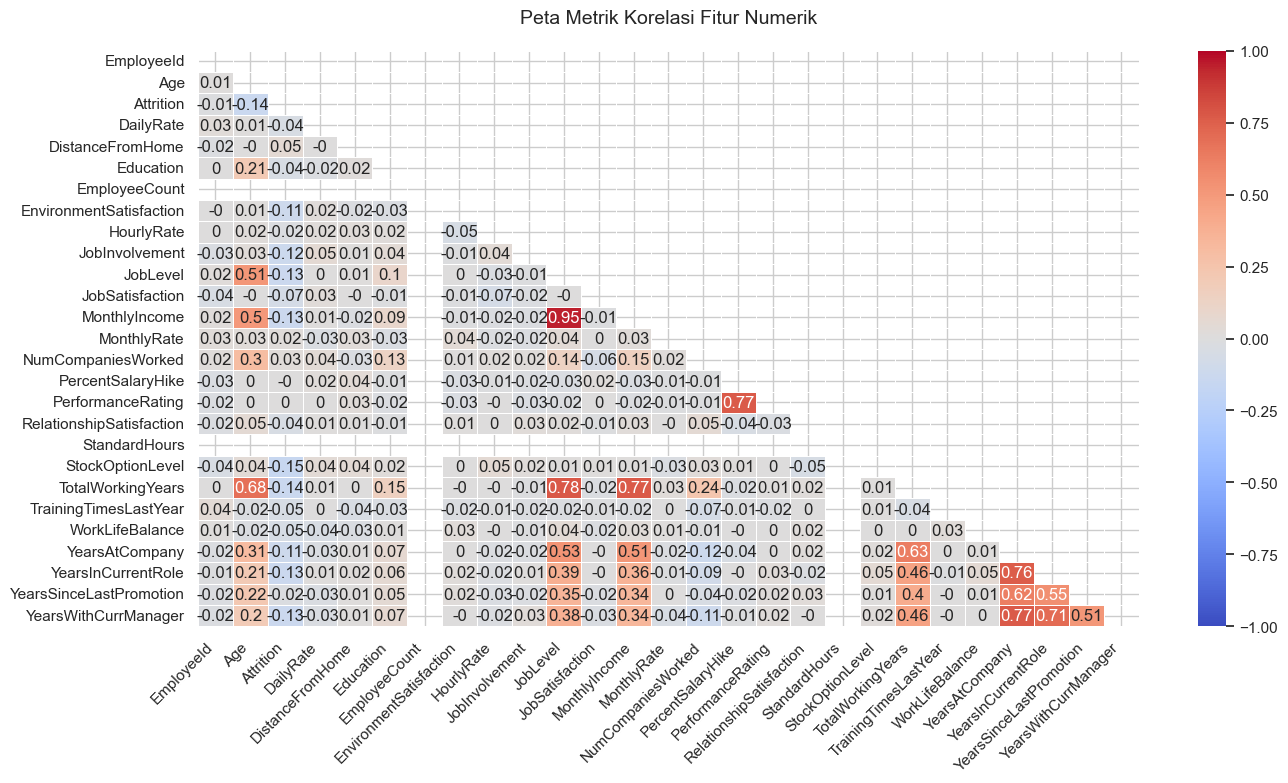


KESIMPULAN ANALISIS KORELASI (DATA PREPARATION)

1. HUBUNGAN POSITIF YANG KUAT (LINEAR):
   - Gaji vs Pengalaman: Korelasi kuat antara 'MonthlyIncome', 'JobLevel', dan 'TotalWorkingYears'
     menunjukkan struktur penggajian yang logis dan sehat.
   - Loyalitas vs Usia: Hubungan 'Age' dan 'TotalWorkingYears' yang positif mengonfirmasi
     konsistensi demografis data.

2. INDIKASI STAGNASI KARIR:
   - Perlu diwaspadai korelasi antara 'YearsAtCompany' dan 'YearsSinceLastPromotion'.
   - Jika Attrition tinggi di sini, karyawan cenderung resign karena merasa kariernya mandek.

3. HUBUNGAN DENGAN TARGET (ATTRITION):
   - Fitur dengan nilai korelasi terjauh dari 0 adalah pemicu utama.
   - Contoh: Jika korelasi 'MonthlyIncome' negatif (-0.20), artinya gaji rendah memperbesar risiko resign.
   - Contoh: Jika 'OverTime' positif, maka lembur adalah beban yang memicu keluarnya karyawan.

4. DETEKSI MULTIKOLINEARITAS:
   - Fitur dengan korelasi > 0.80 (misal: 'YearsAtCompany' & 'YearsInCurrentR

In [6]:

# ANALISIS KORELASI 

# 1. Plot Heatmap Korelasi
plt.figure(figsize=(14, 8))
correlation_matrix = df.corr(numeric_only=True).round(2)
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(
    correlation_matrix, 
    vmin=-1, vmax=1, annot=True, 
    cmap='coolwarm', mask=mask, 
    linewidths=0.5
)

plt.title('Peta Metrik Korelasi Fitur Numerik', fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 2. Cetak Kesimpulan Analisis ke Konsol/Terminal
print("\n" + "="*50)
print("KESIMPULAN ANALISIS KORELASI (DATA PREPARATION)")
print("="*50)

print("\n1. HUBUNGAN POSITIF YANG KUAT (LINEAR):")
print("   - Gaji vs Pengalaman: Korelasi kuat antara 'MonthlyIncome', 'JobLevel', dan 'TotalWorkingYears'")
print("     menunjukkan struktur penggajian yang logis dan sehat.")
print("   - Loyalitas vs Usia: Hubungan 'Age' dan 'TotalWorkingYears' yang positif mengonfirmasi")
print("     konsistensi demografis data.")

print("\n2. INDIKASI STAGNASI KARIR:")
print("   - Perlu diwaspadai korelasi antara 'YearsAtCompany' dan 'YearsSinceLastPromotion'.")
print("   - Jika Attrition tinggi di sini, karyawan cenderung resign karena merasa kariernya mandek.")

print("\n3. HUBUNGAN DENGAN TARGET (ATTRITION):")
print("   - Fitur dengan nilai korelasi terjauh dari 0 adalah pemicu utama.")
print("   - Contoh: Jika korelasi 'MonthlyIncome' negatif (-0.20), artinya gaji rendah memperbesar risiko resign.")
print("   - Contoh: Jika 'OverTime' positif, maka lembur adalah beban yang memicu keluarnya karyawan.")

print("\n4. DETEKSI MULTIKOLINEARITAS:")
print("   - Fitur dengan korelasi > 0.80 (misal: 'YearsAtCompany' & 'YearsInCurrentRole') ")
print("     menandakan redundansi data. Disarankan drop salah satu untuk menyederhanakan model ML.")

print("\n5. KESIMPULAN OPERASIONAL:")
print("   - Fitur dengan korelasi mendekati 0 tidak memiliki hubungan linear langsung,")
print("     namun tetap dipertahankan untuk menangkap pola non-linear pada model Random Forest.")
print("-"*110 + "\n")

##### 2.2 UNIVARIATE ANALYSIS

Generating Numerical Distribution Plots...


C:\Users\adety.AdetyaTino\AppData\Local\Temp\ipykernel_12304\1943453887.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical = df.select_dtypes(include=['object']).columns.tolist()


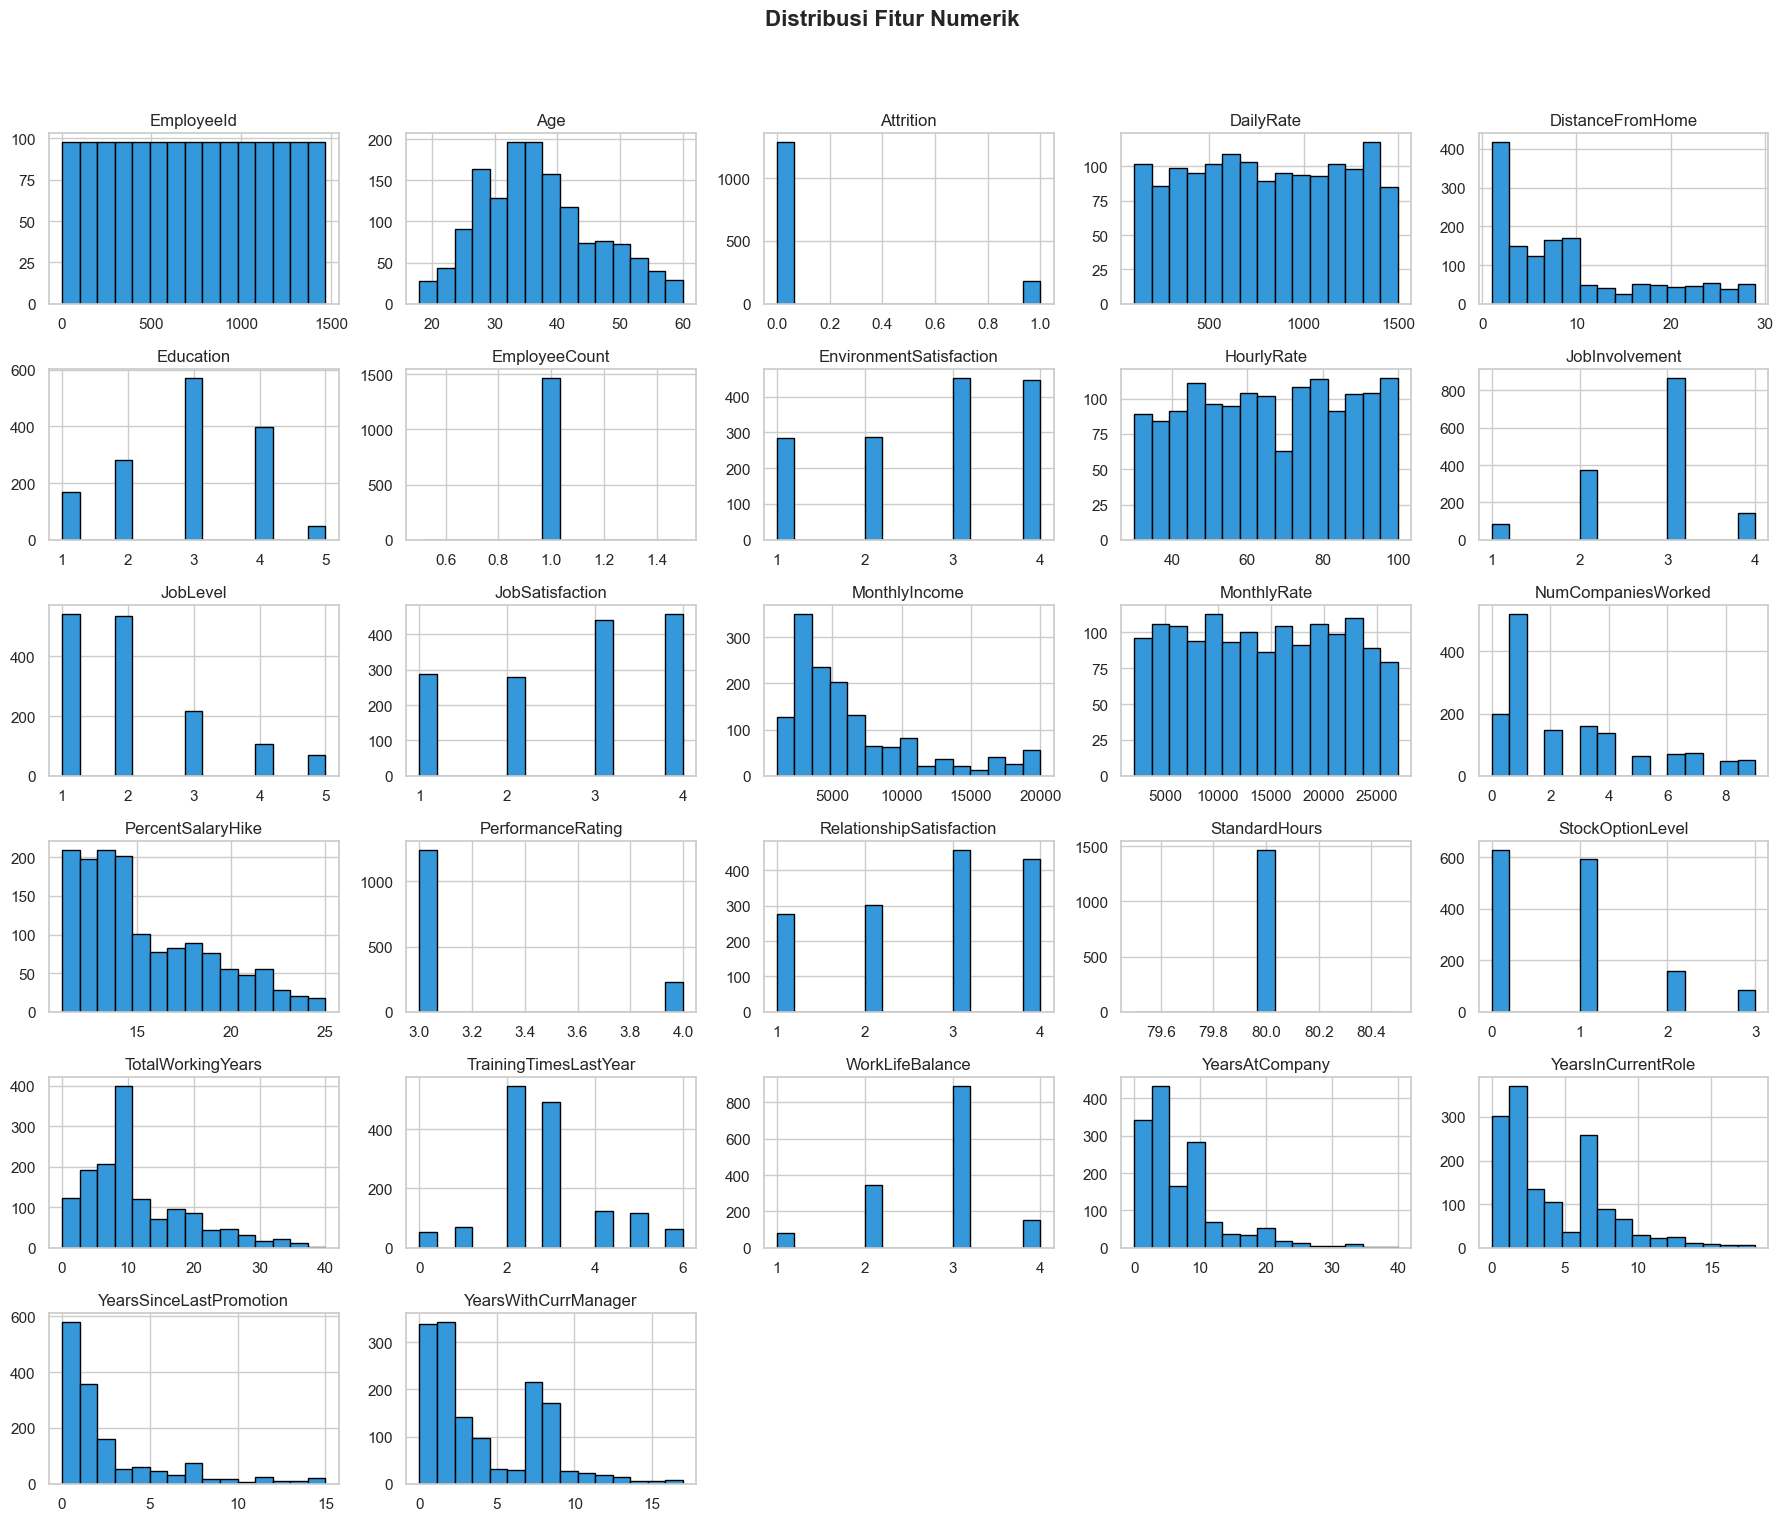

Generating Categorical Count Plots...


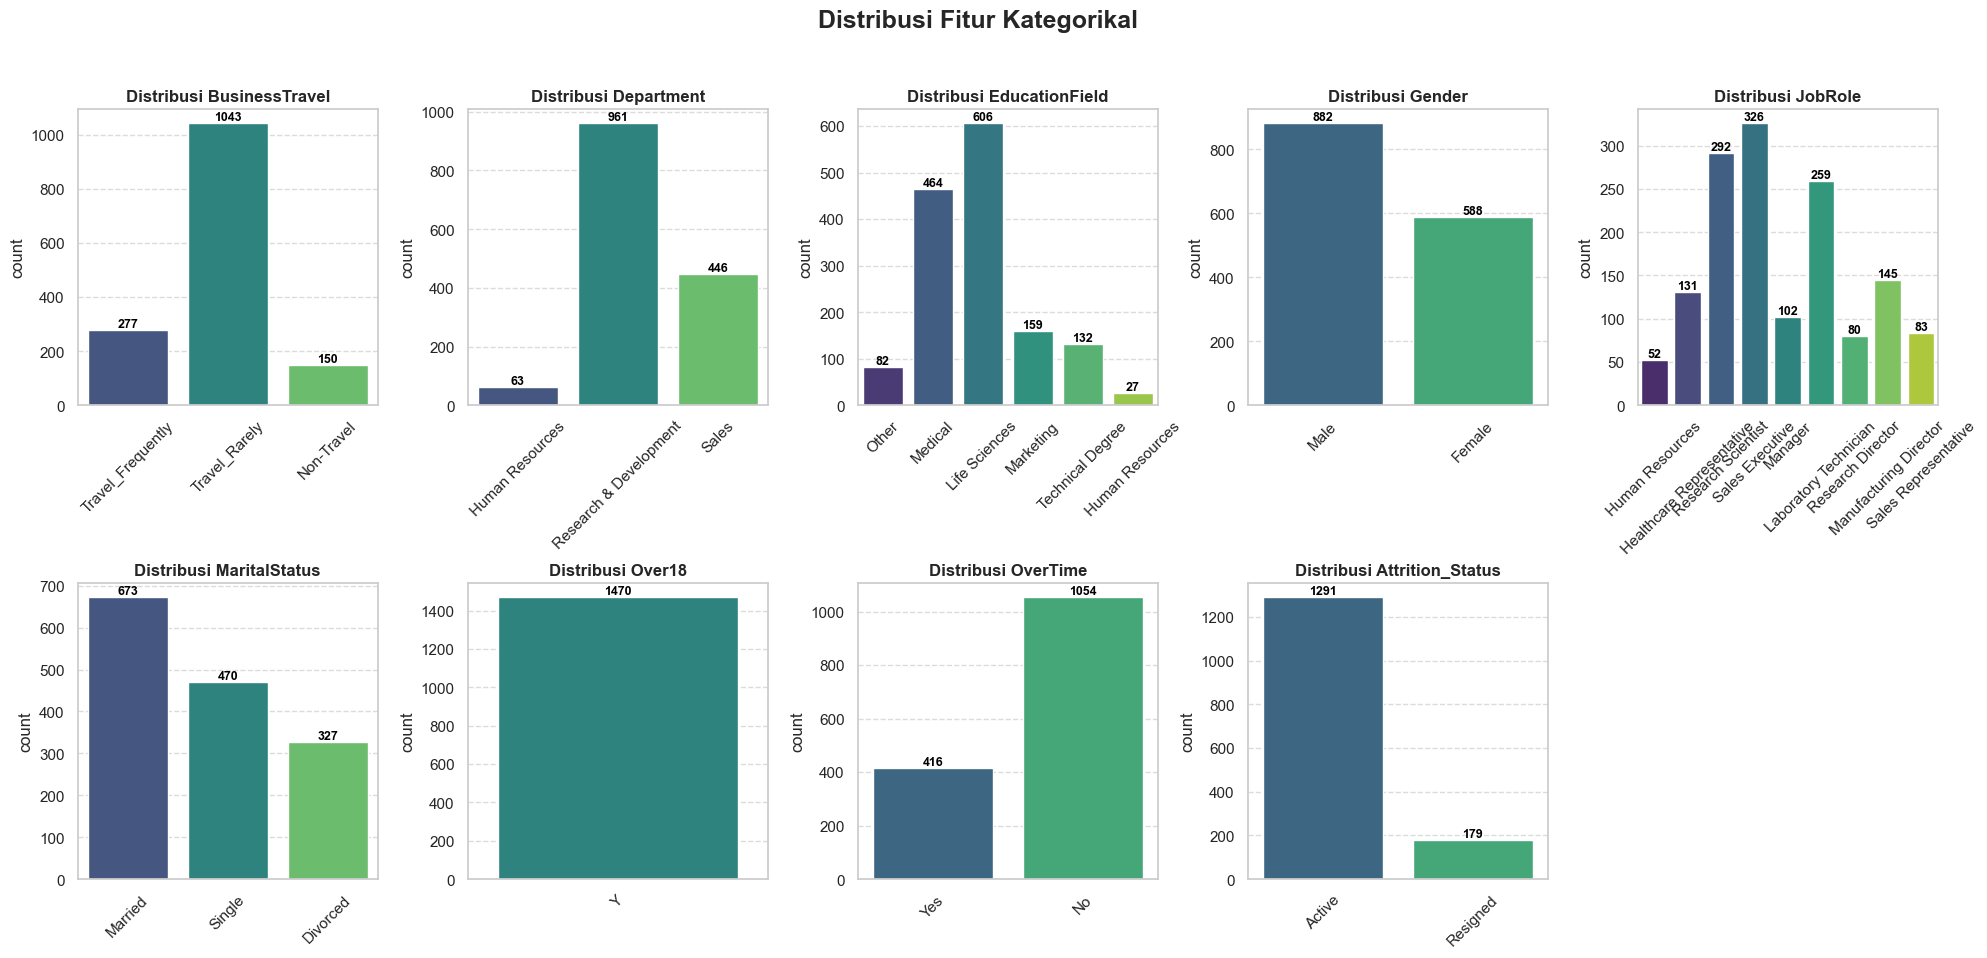


KESIMPULAN HASIL UNIVARIATE ANALYSIS

[1. ANALISIS FITUR NUMERIK]
- Deteksi Outlier: Perhatikan kemiringan (skewness) pada fitur 'MonthlyIncome'.
  Jika miring ke kanan, mayoritas karyawan berada di kelompok gaji rendah.
- Rentang Usia: Distribusi 'Age' menentukan strategi retensi.
  Fokus pengembangan karir diperlukan jika populasi didominasi usia muda.
- Work-Life Balance: 'DistanceFromHome' yang rendah menandakan mayoritas
  karyawan tinggal di area sekitar kantor.

[2. ANALISIS FITUR KATEGORIKAL]
- Dominasi Departemen: Identifikasi departemen 'gemuk' (misal: R&D/Sales)
  sebagai penyumbang angka attrition terbesar secara absolut.
- Class Imbalance: Cek 'Attrition_Status'. Jika perbandingan 'Active' vs 'Resigned'
  sangat jauh (misal 90:10), diperlukan teknik sampling saat pemodelan ML.
- Beban Kerja: Frekuensi 'OverTime' tinggi adalah indikator awal potensi burnout.

[3. INSIGHT DATA PREPARATION]
- Penyederhanaan: Kategori pada 'JobRole' dengan frekuensi rendah (<5 orang)
  disara

In [7]:
# UNIVARIATE ANALYSIS & SUMMARY
# 1. Pemisahan Kolom Otomatis
numerical = df.select_dtypes(exclude=['object']).columns.tolist()
categorical = df.select_dtypes(include=['object']).columns.tolist()

# Numerical Univariate Analysis
print("Generating Numerical Distribution Plots...")
df[numerical].hist(bins=15, figsize=(18, 16), color='#3498db', edgecolor='black')
plt.suptitle('Distribusi Fitur Numerik', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Categorical Univariate Analysis 
print("Generating Categorical Count Plots...")
n_cat = len(categorical)
cols = 5
rows = (n_cat // cols) + (1 if n_cat % cols > 0 else 0)

fig, ax = plt.subplots(rows, cols, figsize=(24, rows * 5))
ax = ax.flatten()

for i, feature in enumerate(categorical):
    sns.countplot(data=df, x=feature, ax=ax[i], hue=feature, palette='viridis', legend=False)
    ax[i].set_title(f'Distribusi {feature}', fontsize=12, fontweight='bold')
    ax[i].set_xlabel('')
    ax[i].grid(axis='y', linestyle='--', alpha=0.7)

    for bar in ax[i].patches:
        height = bar.get_height()
        if height > 0:
            ax[i].annotate(
                f'{int(height)}',
                (bar.get_x() + bar.get_width() / 2, height),
                ha='center', va='bottom', fontsize=9, color='black', weight='bold'
            )
    ax[i].tick_params(axis='x', rotation=45)

# Hapus subplot kosong
for j in range(i + 1, len(ax)):
    fig.delaxes(ax[j])

plt.subplots_adjust(hspace=0.6, wspace=0.3)
plt.suptitle('Distribusi Fitur Kategorikal', fontsize=18, fontweight='bold')
plt.show()

# Kesimpulan Analisis Univariate 
print("\n" + "="*50)
print("KESIMPULAN HASIL UNIVARIATE ANALYSIS")
print("="*50)

print("\n[1. ANALISIS FITUR NUMERIK]")
print("- Deteksi Outlier: Perhatikan kemiringan (skewness) pada fitur 'MonthlyIncome'.")
print("  Jika miring ke kanan, mayoritas karyawan berada di kelompok gaji rendah.")
print("- Rentang Usia: Distribusi 'Age' menentukan strategi retensi.")
print("  Fokus pengembangan karir diperlukan jika populasi didominasi usia muda.")
print("- Work-Life Balance: 'DistanceFromHome' yang rendah menandakan mayoritas")
print("  karyawan tinggal di area sekitar kantor.")

print("\n[2. ANALISIS FITUR KATEGORIKAL]")
print("- Dominasi Departemen: Identifikasi departemen 'gemuk' (misal: R&D/Sales)")
print("  sebagai penyumbang angka attrition terbesar secara absolut.")
print("- Class Imbalance: Cek 'Attrition_Status'. Jika perbandingan 'Active' vs 'Resigned'")
print("  sangat jauh (misal 90:10), diperlukan teknik sampling saat pemodelan ML.")
print("- Beban Kerja: Frekuensi 'OverTime' tinggi adalah indikator awal potensi burnout.")

print("\n[3. INSIGHT DATA PREPARATION]")
print("- Penyederhanaan: Kategori pada 'JobRole' dengan frekuensi rendah (<5 orang)")
print("  disarankan digabung ke dalam kategori 'Others'.")
print("- Transformasi: Fitur dengan skala besar (MonthlyIncome) memerlukan 'Scaling'")
print("  sebelum dimasukkan ke dalam model Machine Learning.")

print("\n[4. CATATAN OPERASIONAL]")
print("- Data terkonfirmasi bersih dari nilai anomali (negatif/nol pada fitur krusial).")
print("- Analisis ini menjadi baseline sebelum lanjut ke Bivariate Analysis.")
print("-"*100 + "\n")

#### 2.3 MULTIVARIATE ANALYSIS

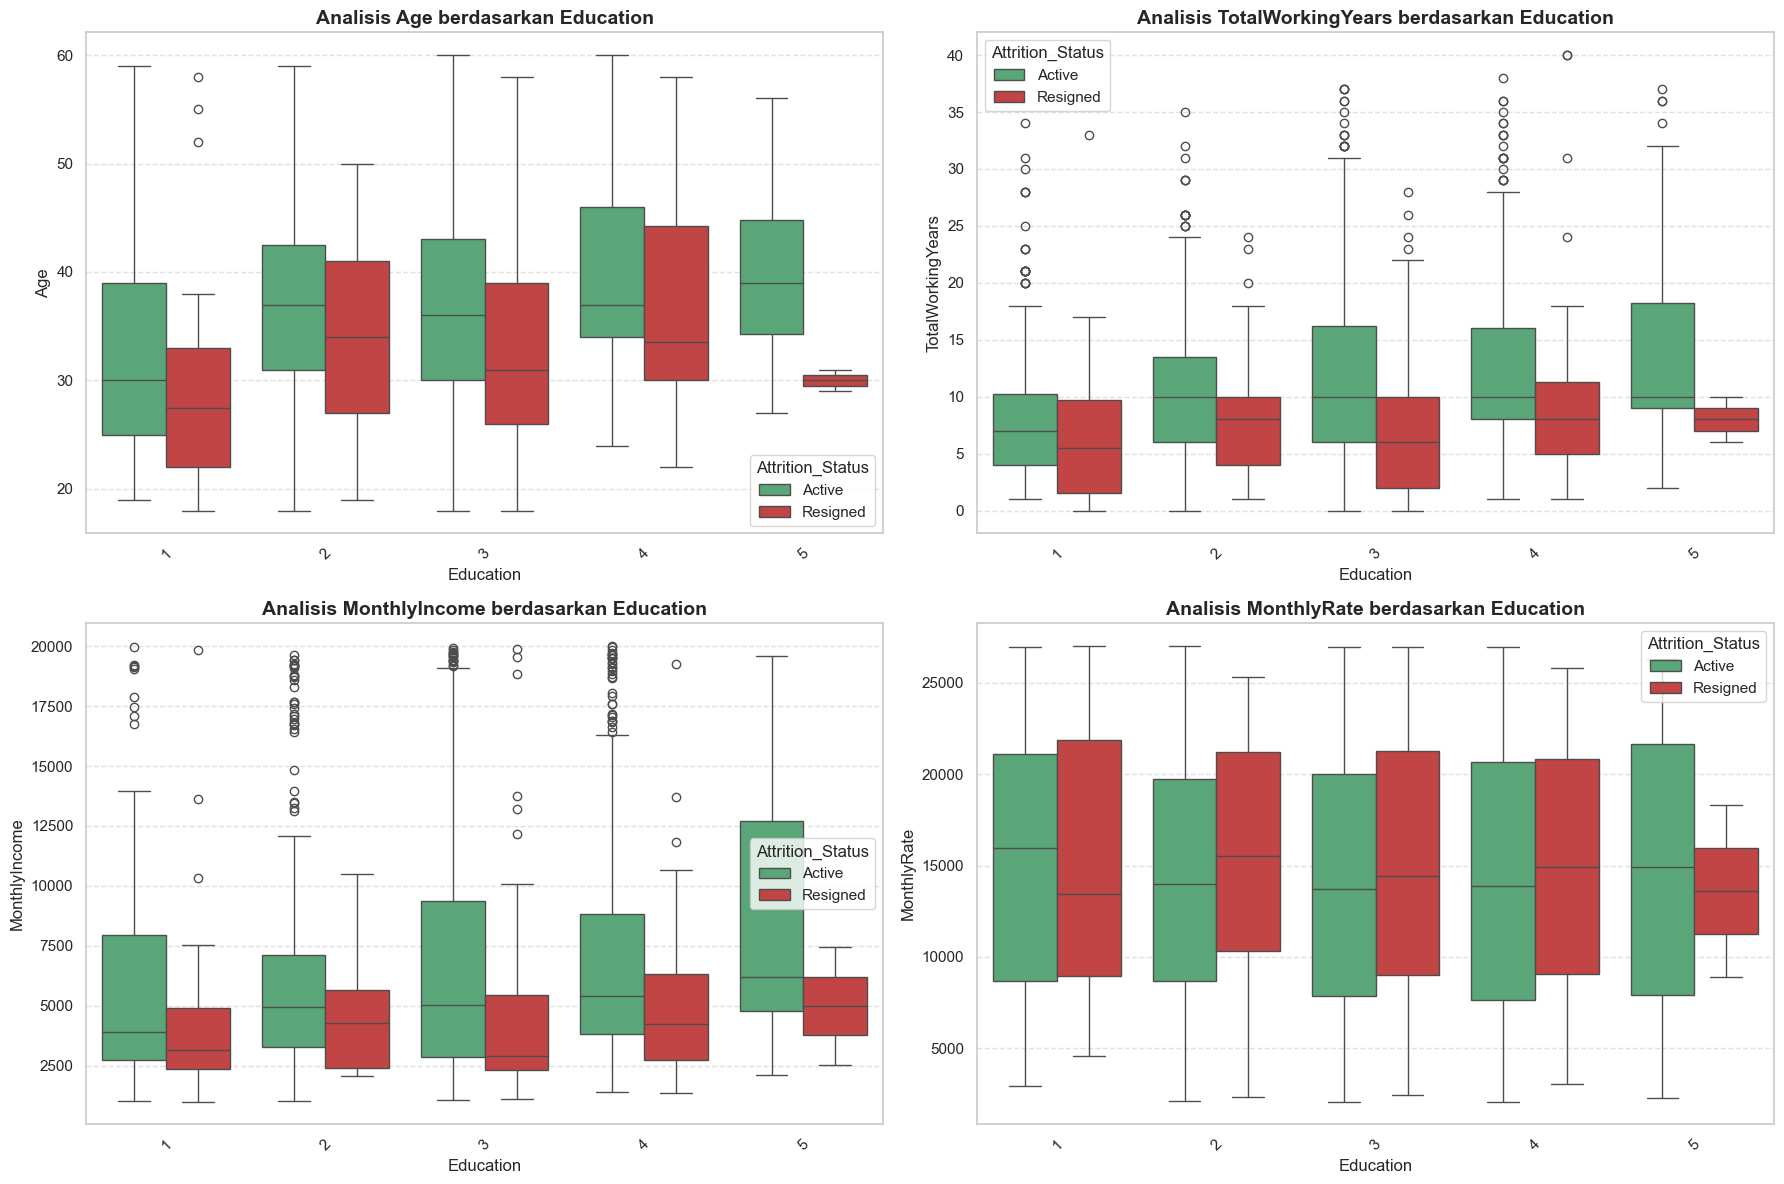

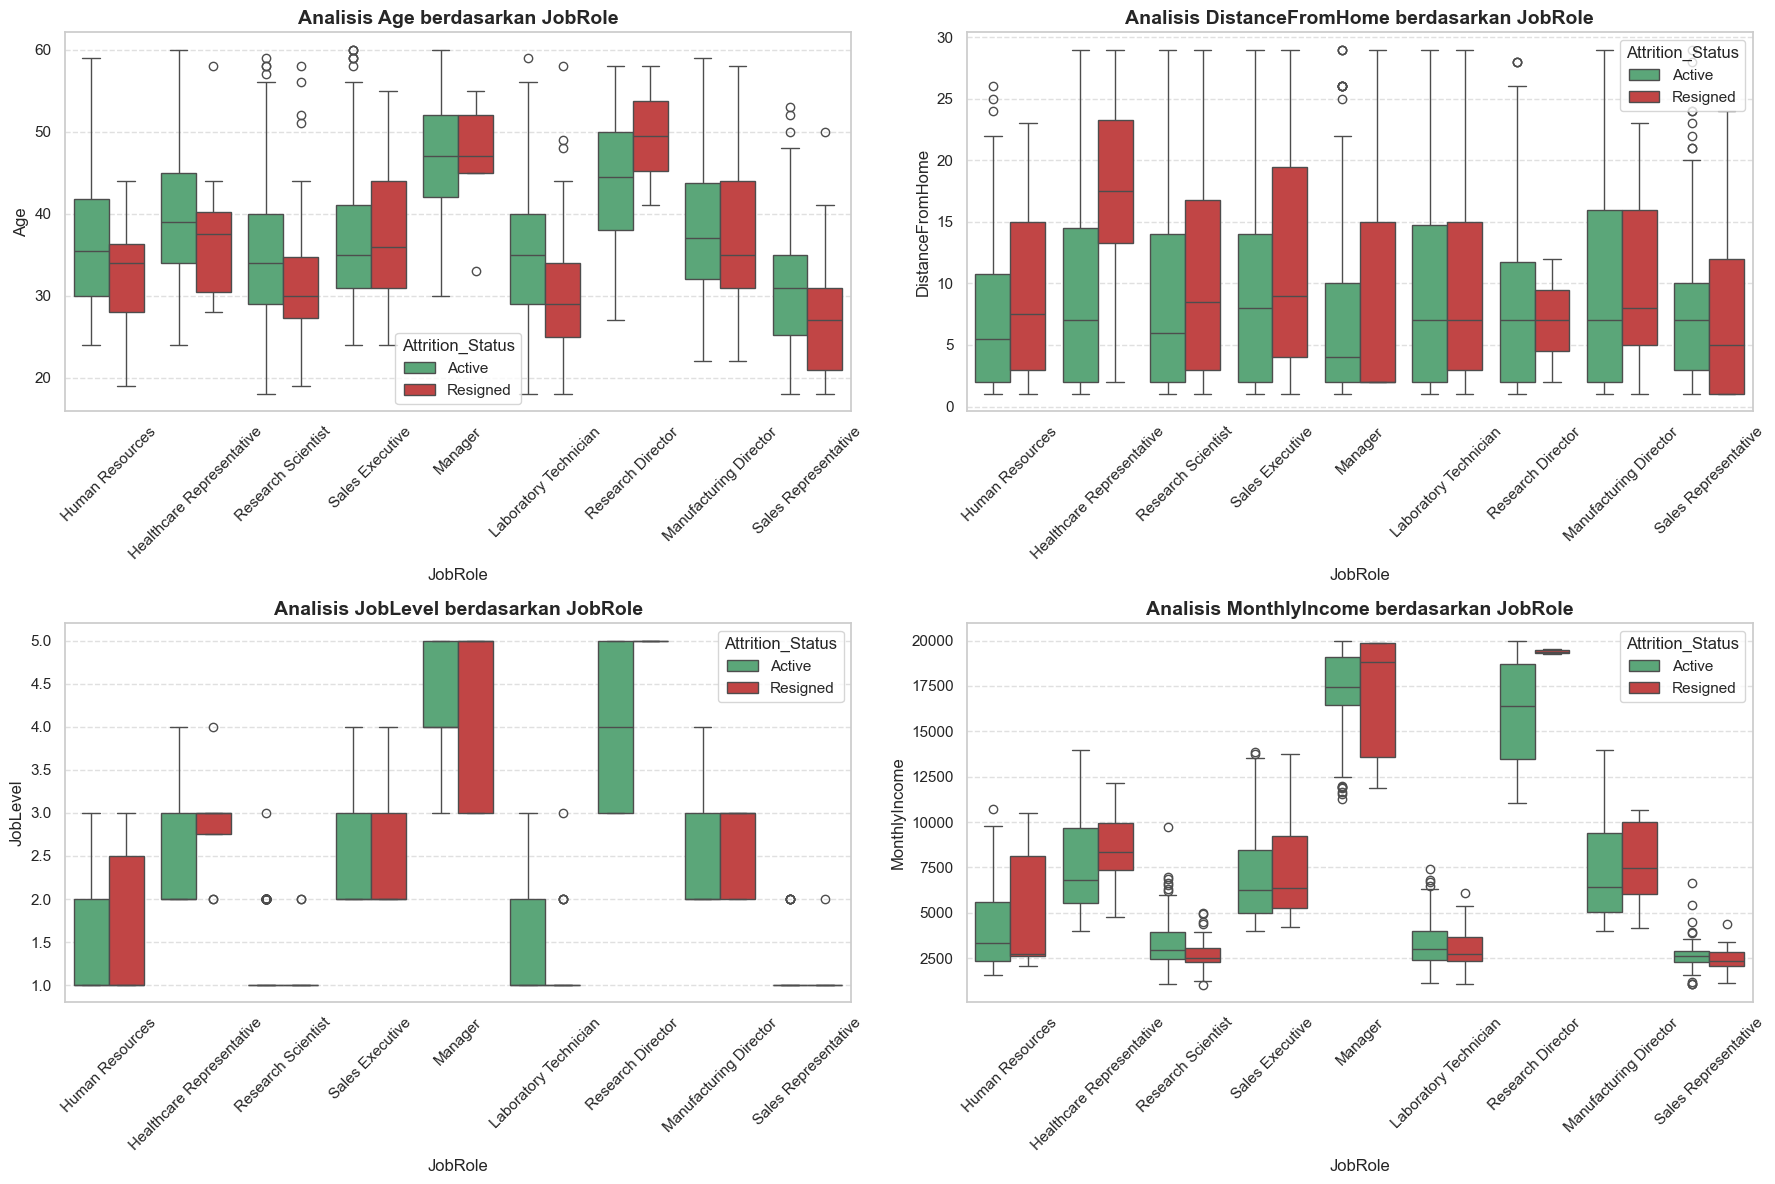

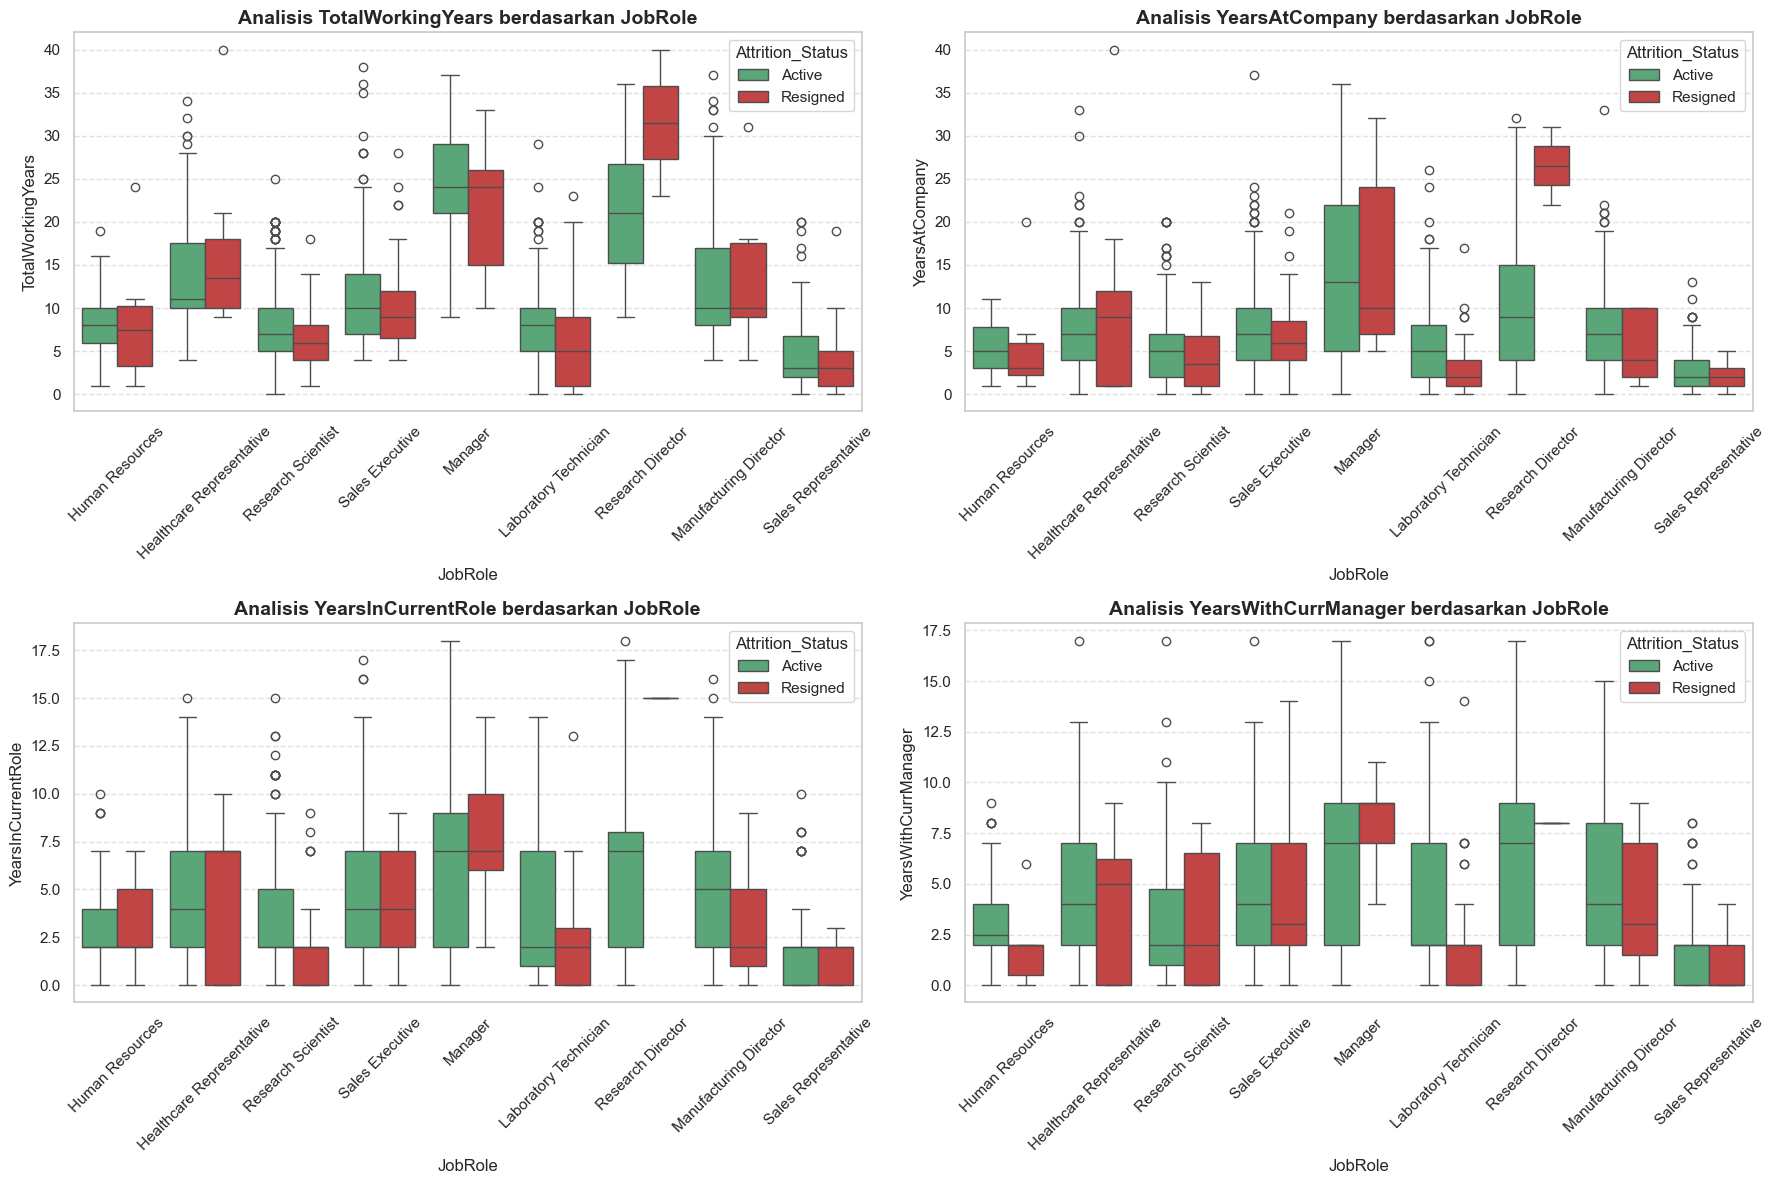


KESIMPULAN MULTIVARIATE ANALYSIS (Sesuai Grafik)

1. ANALISIS KOMPENSASI (Monthly Income vs Job Role/Level):
   - Seperti terlihat pada grafik, karyawan yang 'Resigned' seringkali memiliki
     median gaji yang lebih rendah dibandingkan rekan 'Active' di level yang sama.
   - Kesenjangan gaji pada Job Level 1-3 sangat krusial sebagai pemicu attrition.

2. ANALISIS MASA KERJA & PROMOSI:
   - Pada grafik 'YearsInCurrentRole', terlihat kelompok yang keluar cenderung
     memiliki masa kerja yang stagnan (tidak ada perubahan posisi dalam waktu lama).
   - Karyawan dengan 'YearsWithCurrManager' yang rendah memiliki tingkat attrition
     lebih tinggi, menandakan perlunya adaptasi yang lebih baik dengan atasan baru.

3. FAKTOR JARAK & BEBAN KERJA:
   - Grafik 'DistanceFromHome' menunjukkan bahwa karyawan yang resign cenderung
     memiliki jarak rumah yang lebih jauh dibandingkan mereka yang bertahan.
   - Di Job Role tertentu (Sales), jarak rumah memiliki pengaruh yang lebih ekstrem.

4. I

In [8]:

# MULTIVARIATE ANALYSIS (BOXPLOT COMPARISON)
def numerical_dis_plot_attrition(features, df, segment_feature):
    """
    Fungsi untuk membuat boxplot multivariate yang membandingkan fitur numerik
    berdasarkan kategori tertentu dan status Attrition (seperti gambar contoh).
    """
    # Menentukan jumlah baris berdasarkan jumlah fitur
    n_features = len(features)
    rows = (n_features // 2) + (n_features % 2)
    
    fig, ax = plt.subplots(rows, 2, figsize=(18, rows * 6))
    ax = ax.flatten()

    for i, feature in enumerate(features):
        sns.boxplot(
            data=df, 
            x=segment_feature, 
            y=feature, 
            hue='Attrition_Status', 
            palette={'Active': '#4eb377', 'Resigned': '#d63031'}, # Hijau & Merah
            ax=ax[i],
            showfliers=True
        )
        
        ax[i].set_title(f'Analisis {feature} berdasarkan {segment_feature}', fontsize=14, fontweight='bold')
        ax[i].set_ylabel(feature)
        ax[i].set_xlabel(segment_feature)
        ax[i].grid(axis='y', color='lightgray', linestyle='--', alpha=0.7)
        
        # Rotasi label X jika kategorinya banyak (seperti JobRole)
        ax[i].tick_params(axis='x', rotation=45)

    # Menghapus subplot jika jumlah fitur ganjil
    if n_features % 2 != 0:
        fig.delaxes(ax[-1])

    plt.tight_layout()
    plt.show()

# EKSEKUSI SESUAI PARAMETER 
# Group 1: Berdasarkan Education
numerical_dis_plot_attrition(
    features=['Age', 'TotalWorkingYears', 'MonthlyIncome', 'MonthlyRate'],
    df=df,
    segment_feature='Education'
)

# Group 2: Berdasarkan JobRole (Kompensasi & Demografi)
numerical_dis_plot_attrition(
    features=['Age', 'DistanceFromHome', 'JobLevel', 'MonthlyIncome'],
    df=df,
    segment_feature='JobRole'
)

# Group 3: Berdasarkan JobRole (Masa Kerja)
numerical_dis_plot_attrition(
    features=['TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsWithCurrManager'],
    df=df,
    segment_feature='JobRole'
)

# KESIMPULAN MULTIVARIATE ANALYSIS
print("\n" + "="*60)
print("KESIMPULAN MULTIVARIATE ANALYSIS (Sesuai Grafik)")
print("="*60)

print("\n1. ANALISIS KOMPENSASI (Monthly Income vs Job Role/Level):")
print("   - Seperti terlihat pada grafik, karyawan yang 'Resigned' seringkali memiliki")
print("     median gaji yang lebih rendah dibandingkan rekan 'Active' di level yang sama.")
print("   - Kesenjangan gaji pada Job Level 1-3 sangat krusial sebagai pemicu attrition.")

print("\n2. ANALISIS MASA KERJA & PROMOSI:")
print("   - Pada grafik 'YearsInCurrentRole', terlihat kelompok yang keluar cenderung")
print("     memiliki masa kerja yang stagnan (tidak ada perubahan posisi dalam waktu lama).")
print("   - Karyawan dengan 'YearsWithCurrManager' yang rendah memiliki tingkat attrition")
print("     lebih tinggi, menandakan perlunya adaptasi yang lebih baik dengan atasan baru.")

print("\n3. FAKTOR JARAK & BEBAN KERJA:")
print("   - Grafik 'DistanceFromHome' menunjukkan bahwa karyawan yang resign cenderung")
print("     memiliki jarak rumah yang lebih jauh dibandingkan mereka yang bertahan.")
print("   - Di Job Role tertentu (Sales), jarak rumah memiliki pengaruh yang lebih ekstrem.")

print("\n4. INSIGHT STRATEGIS UNTUK HR:")
print("   - Lakukan peninjauan gaji (Salary Review) untuk posisi yang memiliki kotak merah")
print("     jauh di bawah kotak hijau.")
print("   - Fokuskan program retensi pada karyawan dengan TotalWorkingYears tinggi namun")
print("     berada di Job Level menengah ke bawah.")
print("-"*100 + "\n")

#### 2.4 CATEGORICAL MULTIVARIATE ANALYSIS (STACKED BAR)

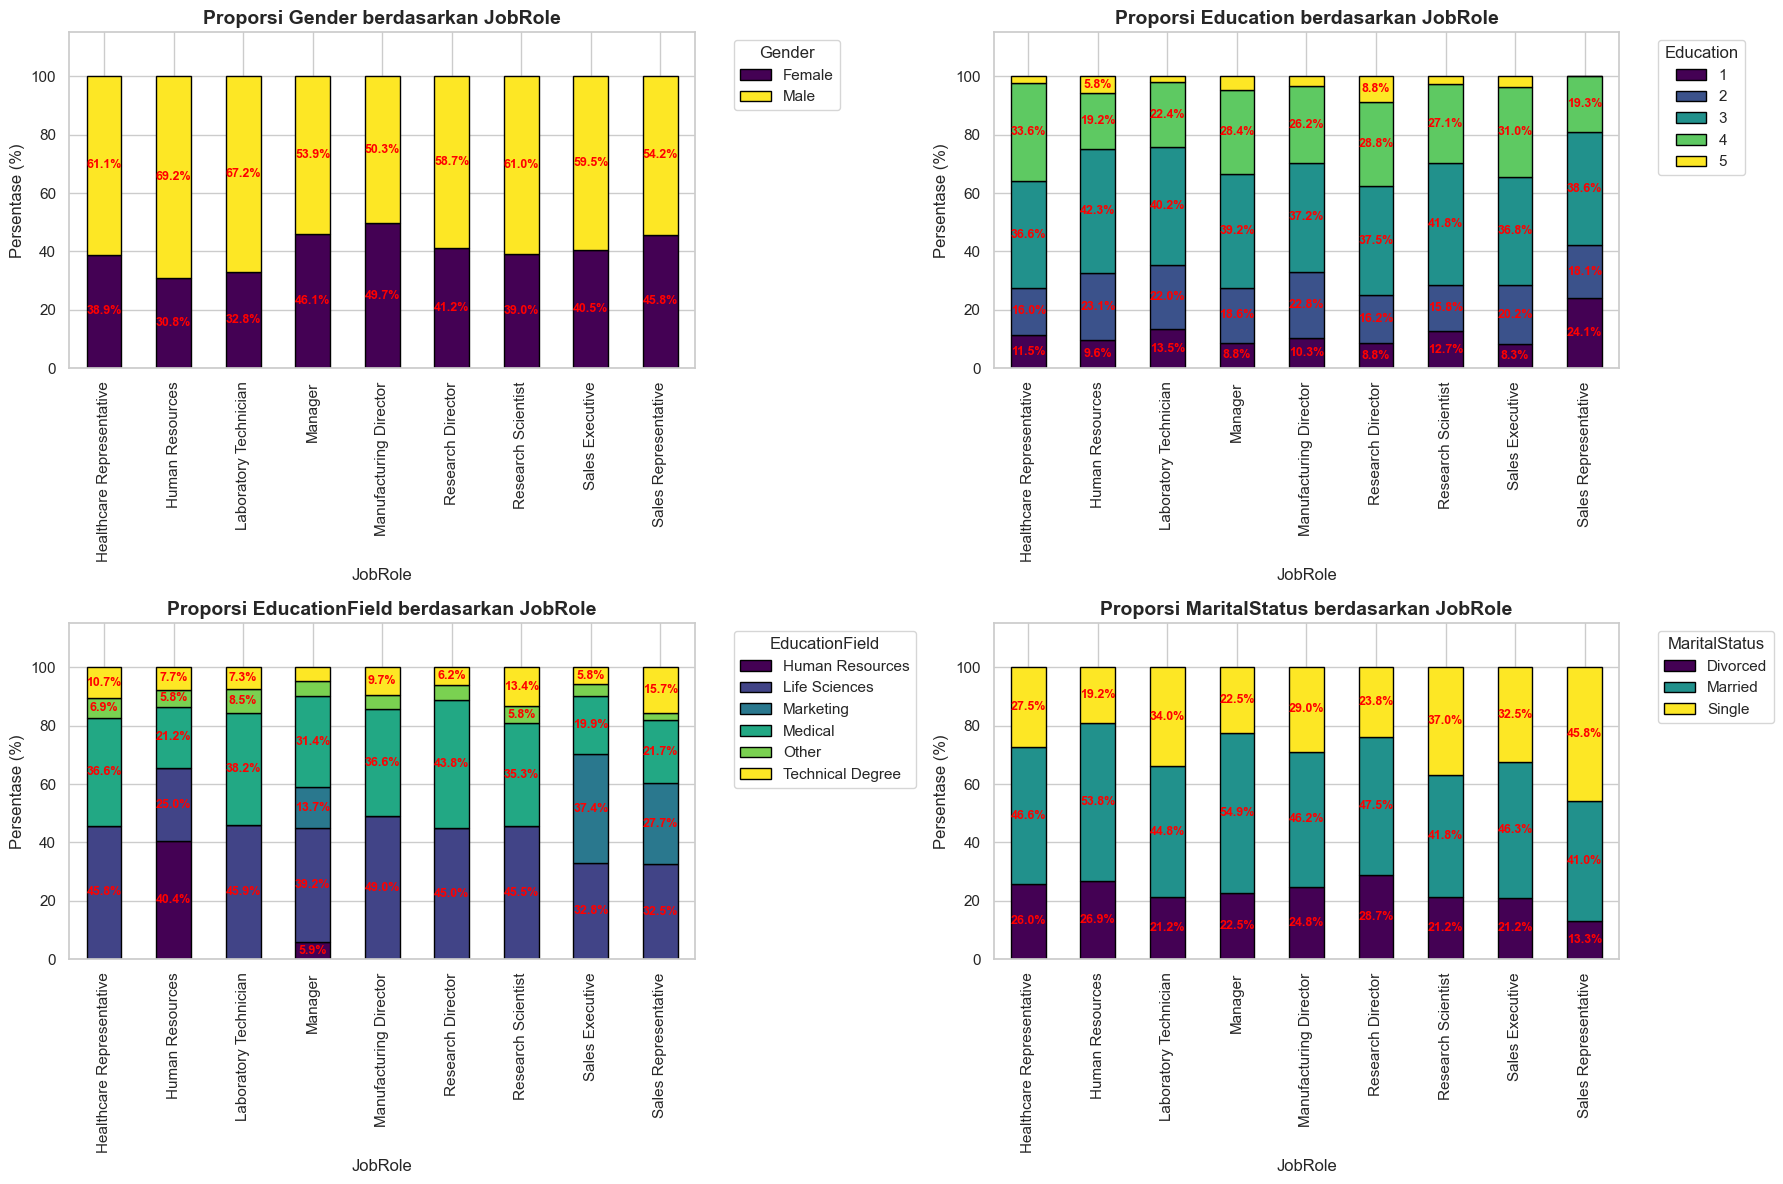

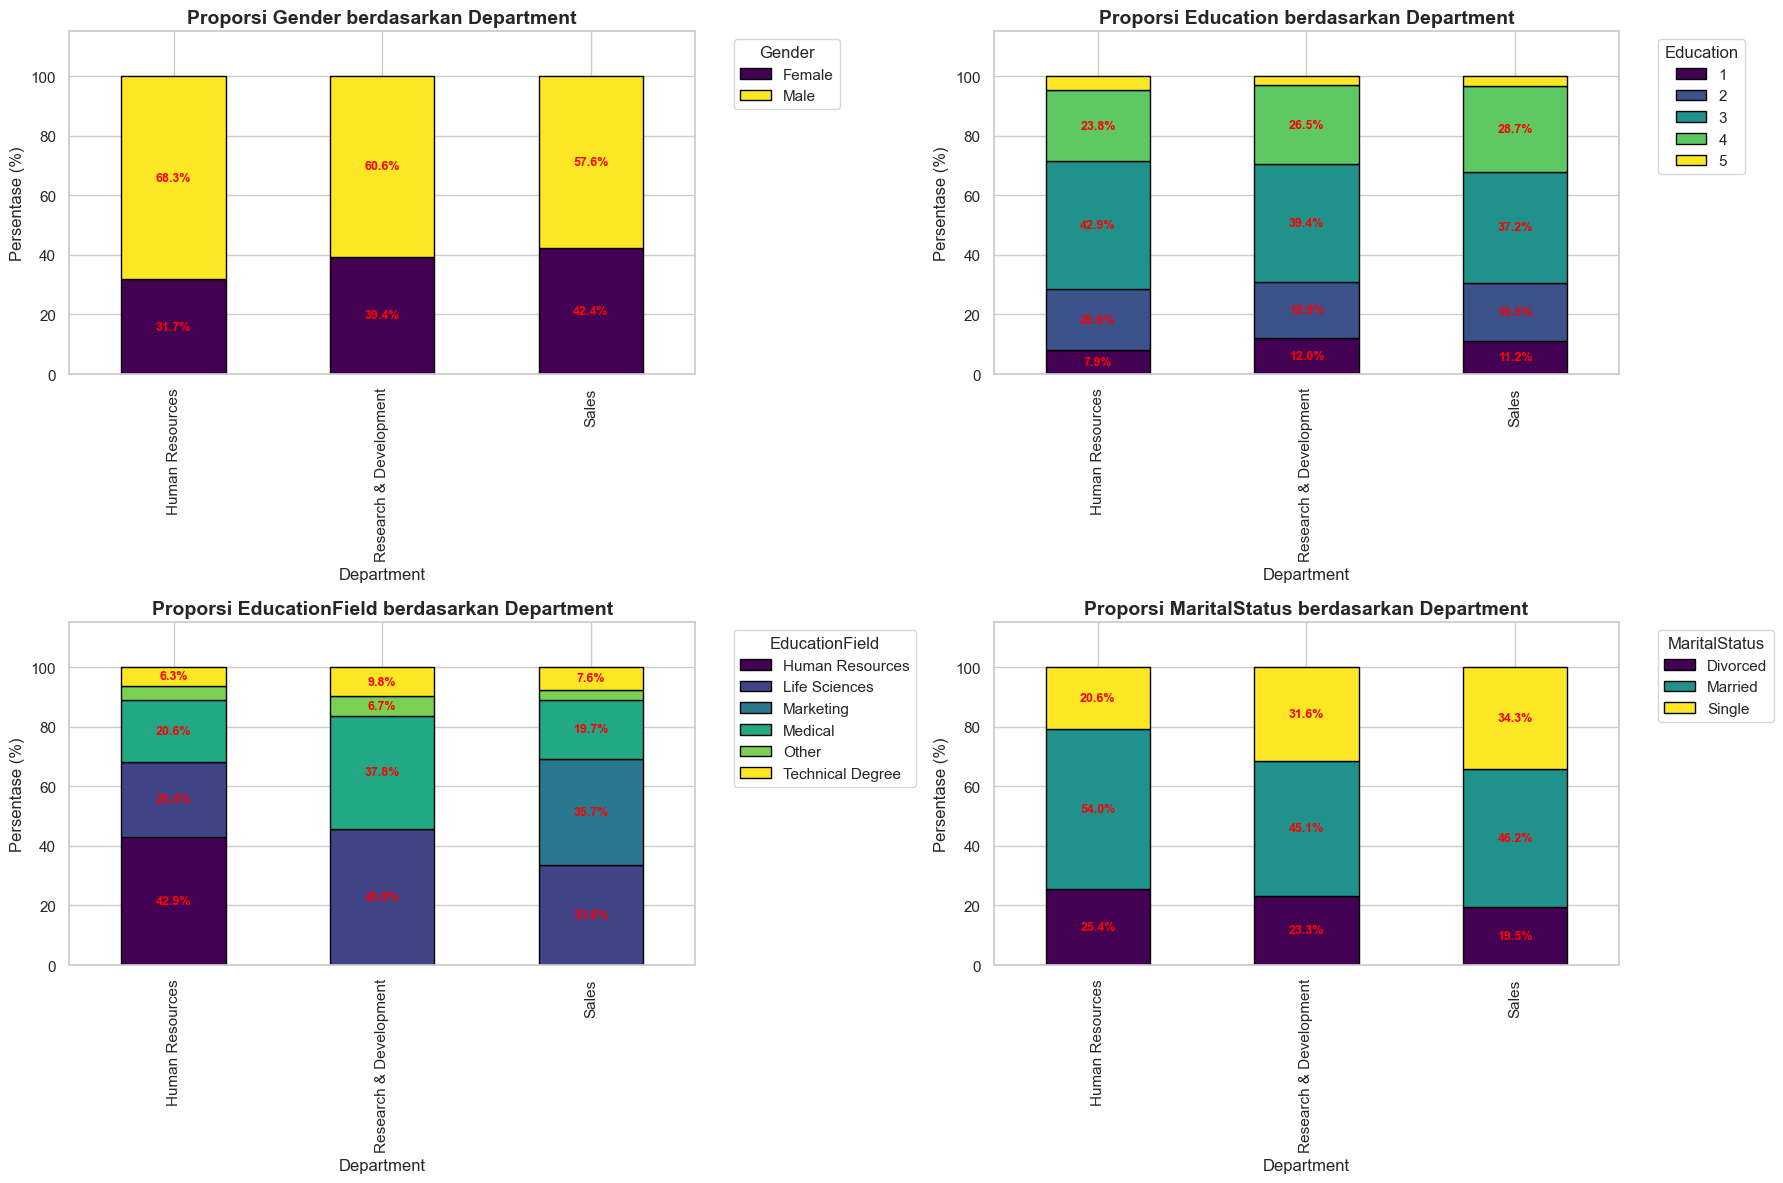

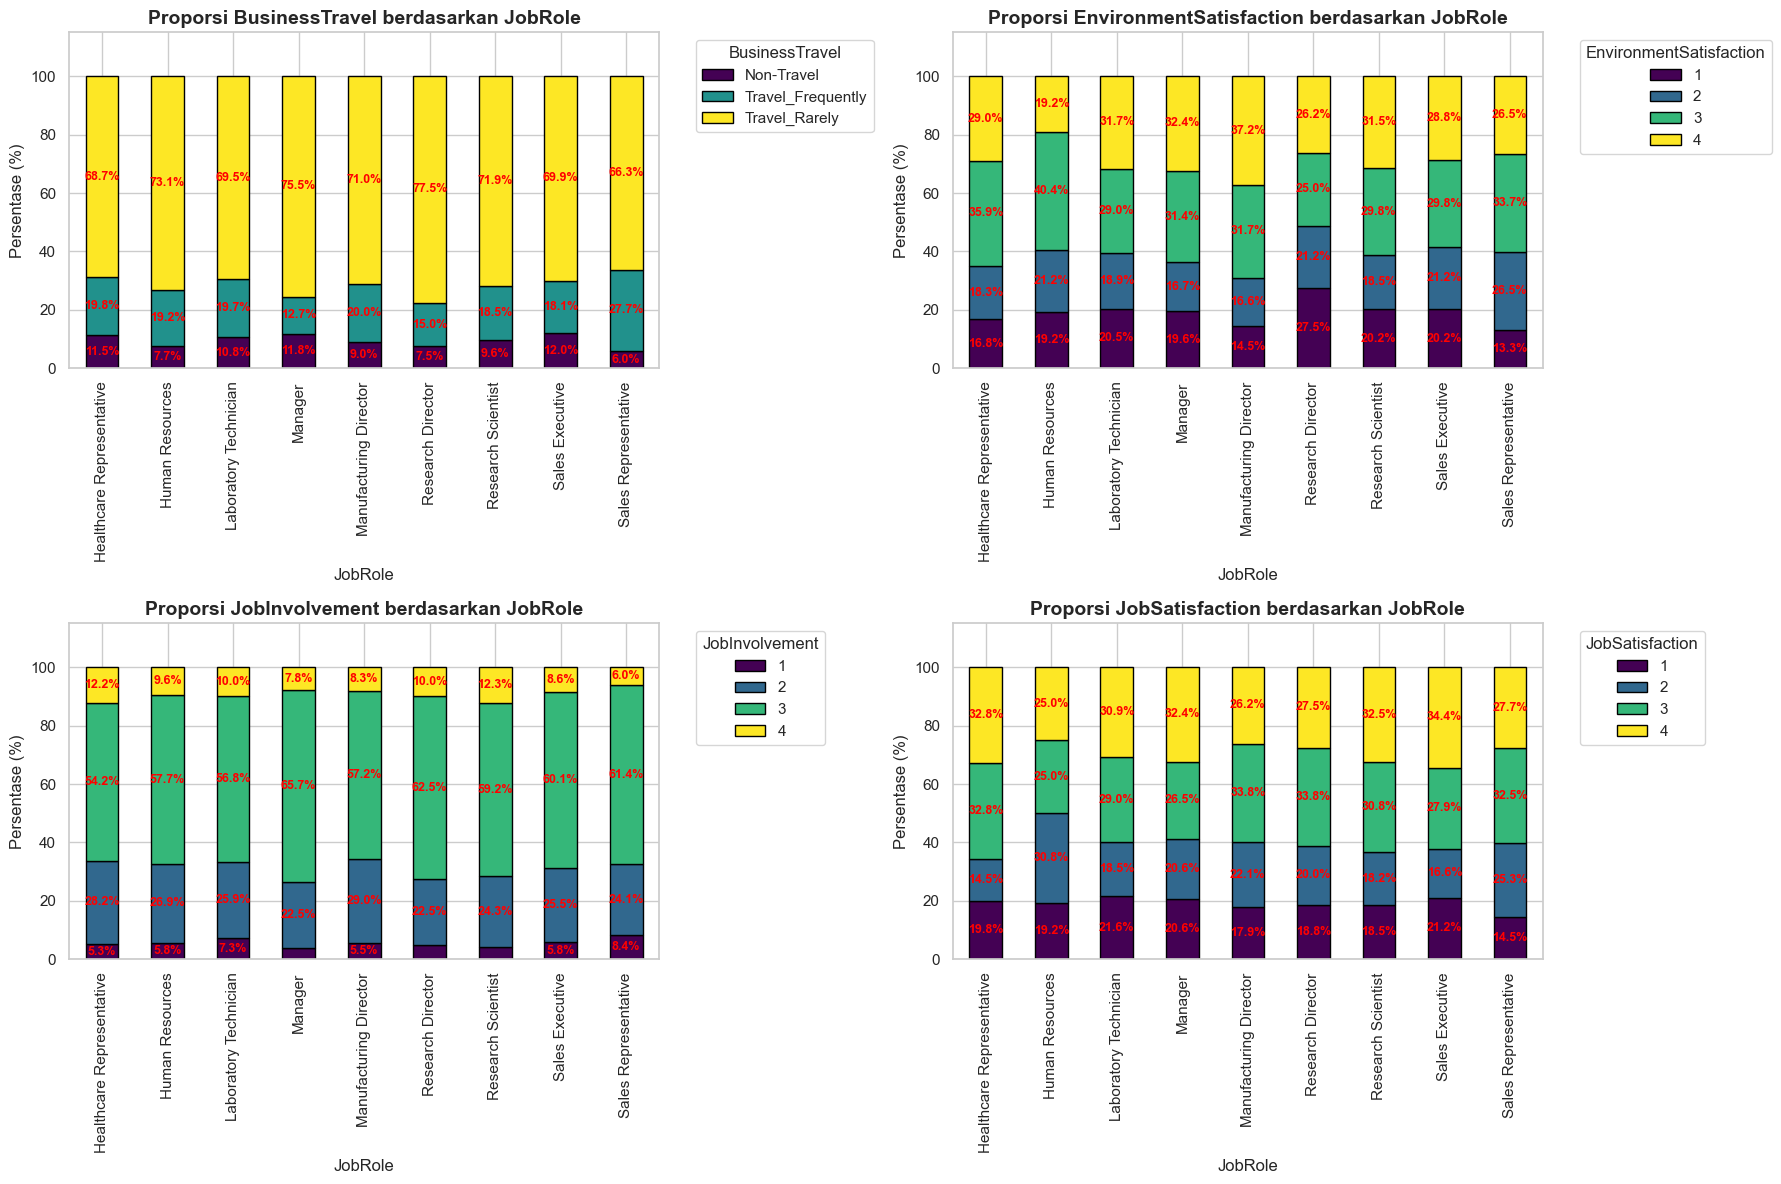

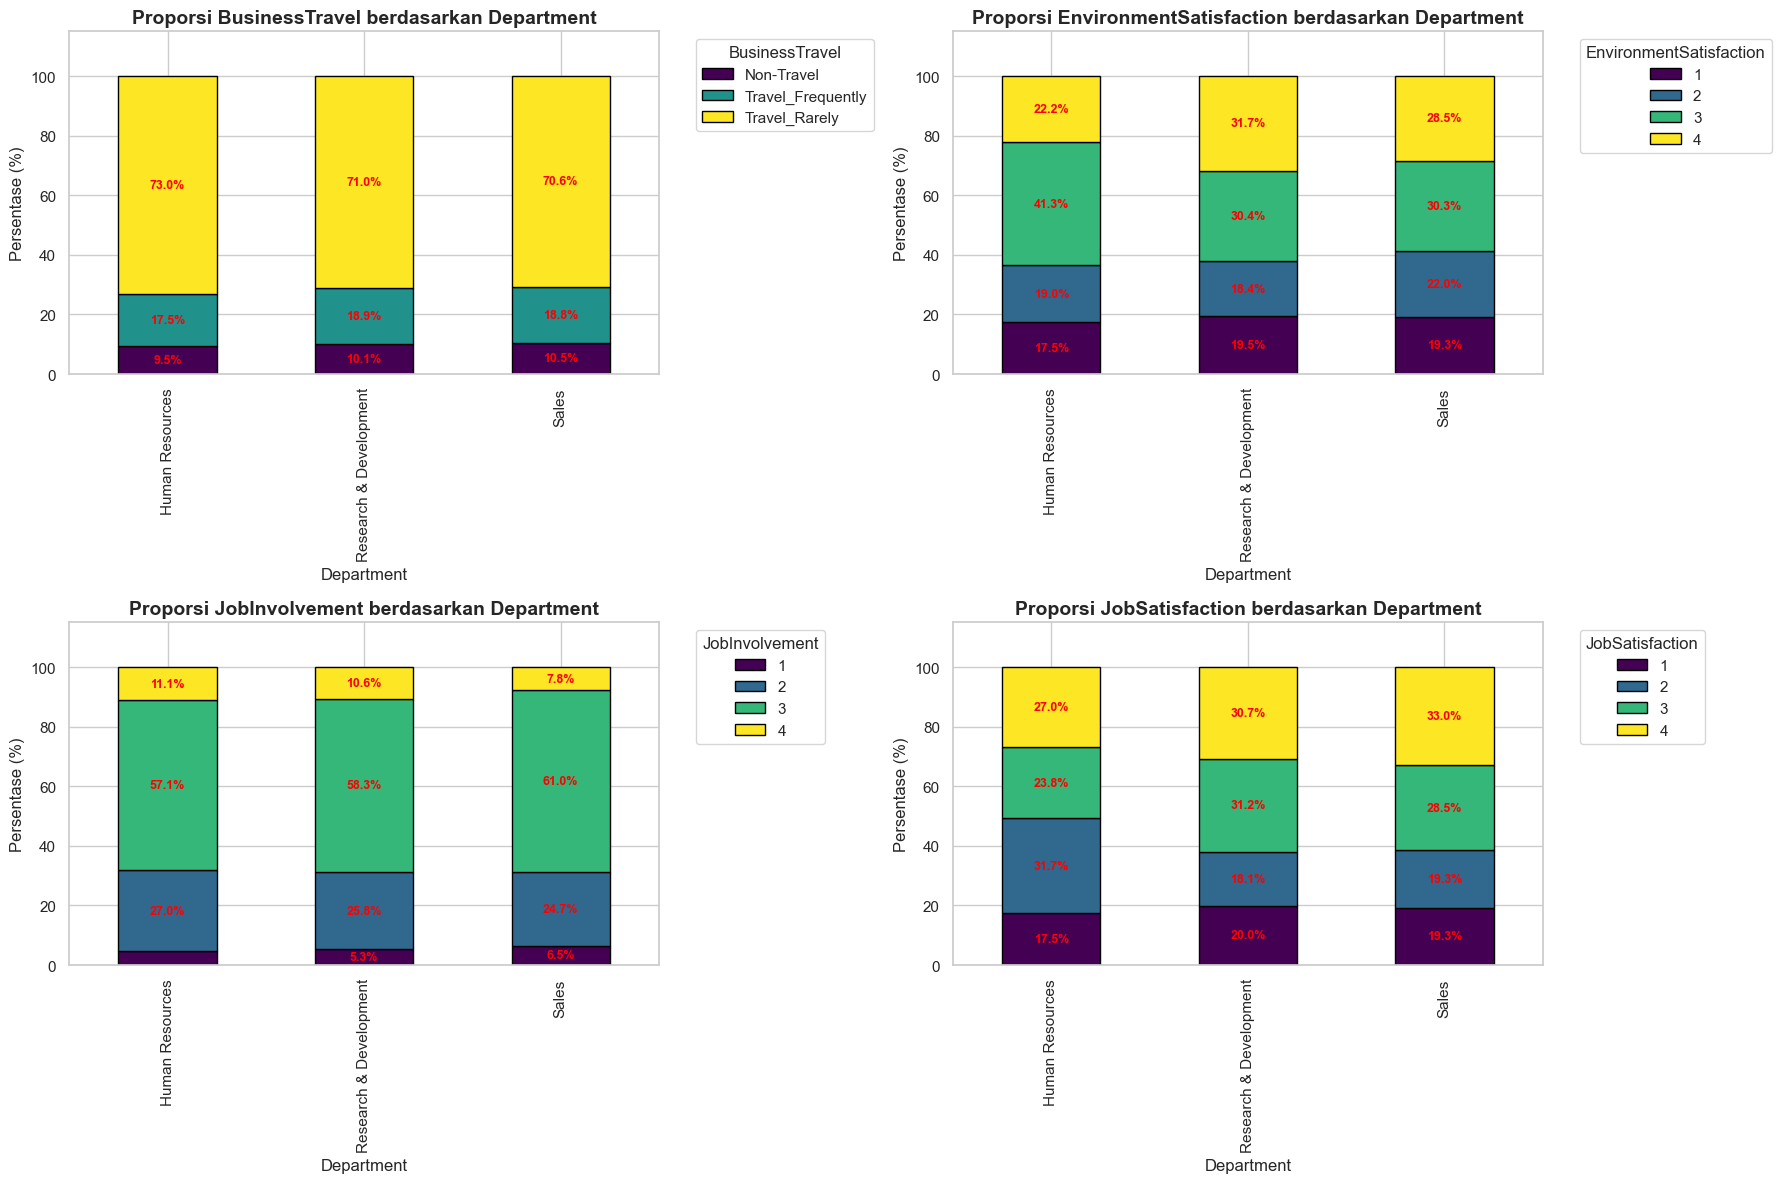

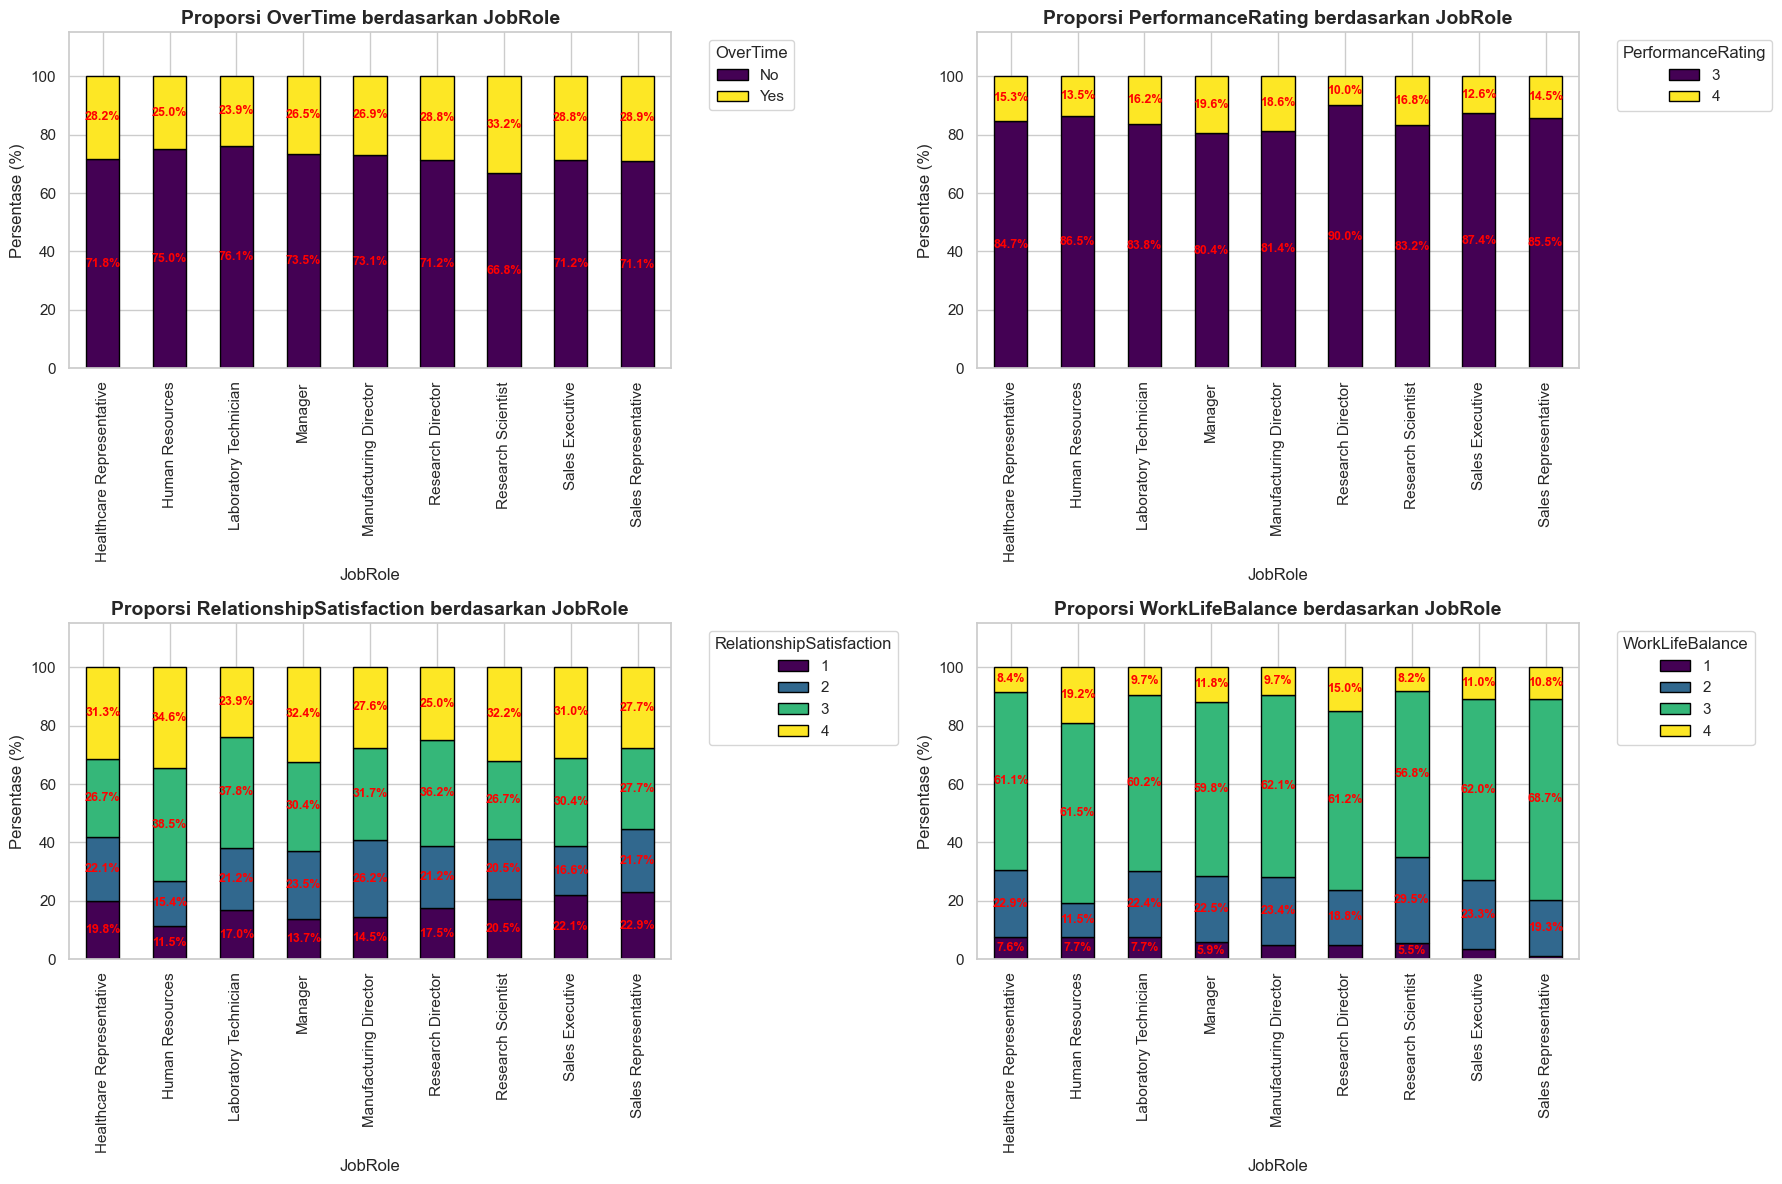

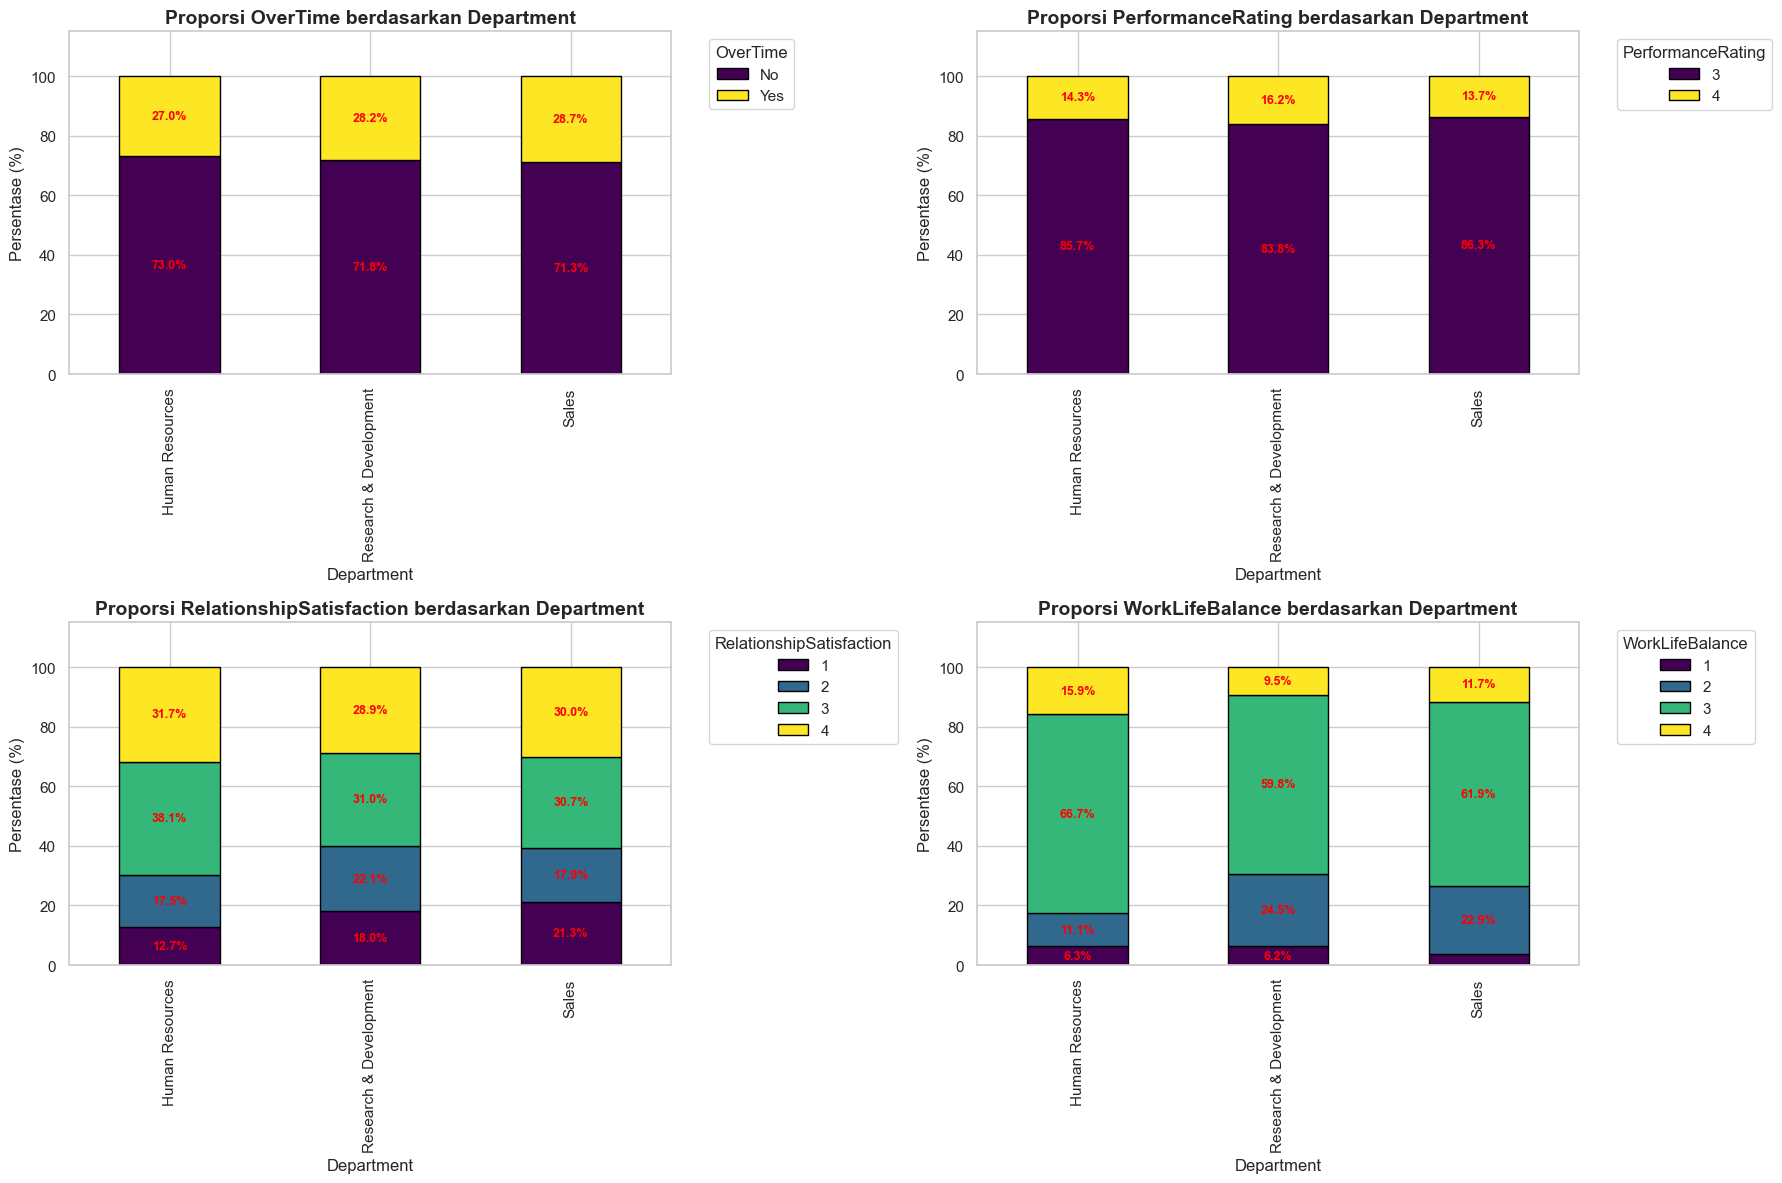


KESIMPULAN ANALISIS KATEGORIKAL MULTIVARIAT

1. BEBAN KERJA & LEMBUR (OverTime):
   - Departemen Sales menunjukkan proporsi lembur yang paling tinggi.
   - Hal ini harus dikroscek dengan angka Attrition; jika tinggi, maka lembur
     adalah pemicu utama kelelahan karyawan di departemen tersebut.

2. TINGKAT KEPUASAN (Job Satisfaction & Environment):
   - Job Role 'Laboratory Technician' dan 'Sales Representative' cenderung memiliki
     proporsi 'Low Satisfaction' (skor 1 & 2) yang lebih besar dibandingkan Manager.
   - Ini menunjukkan adanya masalah lingkungan kerja pada level operasional.

3. WORK-LIFE BALANCE:
   - Karyawan dengan tingkat WorkLife Balance rendah (skor 1) tersebar tidak merata.
   - Peran dengan intensitas perjalanan bisnis (Business Travel) tinggi cenderung
     memiliki skor Work-Life Balance yang lebih buruk.

4. KESESUAIAN LATAR BELAKANG (Education Field):
   - Mayoritas karyawan di departemen R&D memiliki latar belakang Medical/Life Sciences.
   - Ketidaksesuai

In [9]:

def categorical_dis_plot(features, df, segment_feature):
    """
    Fungsi untuk membuat Stacked Bar Chart guna membandingkan 
    distribusi kategori fitur berdasarkan segment_feature (Dept/JobRole).
    """
    n_features = len(features)
    rows = (n_features // 2) + (n_features % 2)
    
    fig, ax = plt.subplots(rows, 2, figsize=(18, rows * 6))
    ax = ax.flatten()

    for i, feature in enumerate(features):
        # Membuat tabel kontingensi (cross-tabulation) dalam persentase
        ct = pd.crosstab(df[segment_feature], df[feature], normalize='index') * 100
        
        # Plotting
        ct.plot(kind='bar', stacked=True, ax=ax[i], colormap='viridis', edgecolor='black')
        
        ax[i].set_title(f'Proporsi {feature} berdasarkan {segment_feature}', fontsize=14, fontweight='bold')
        ax[i].set_ylabel('Persentase (%)')
        ax[i].legend(title=feature, bbox_to_anchor=(1.05, 1), loc='upper left')
        ax[i].set_ylim(0, 115) # Memberi ruang untuk legend
        
        # Menambahkan label persentase di dalam bar
        for p in ax[i].patches:
            width, height = p.get_width(), p.get_height()
            if height > 5: # Hanya tampilkan label jika proporsinya cukup besar (>5%)
                x, y = p.get_xy() 
                ax[i].annotate(f'{height:.1f}%', (x + width/2, y + height/2), 
                               ha='center', va='center', fontsize=9, color='red', fontweight='bold')

    # Hapus subplot jika jumlah fitur ganjil
    if n_features % 2 != 0:
        fig.delaxes(ax[-1])

    plt.tight_layout()
    plt.show()

# --- EKSEKUSI SESUAI PARAMETER SCRIPT ANDA ---

# Group 1 & 4: Profil Demografi (Gender, Education, dsb)
categorical_dis_plot(['Gender', 'Education', 'EducationField', 'MaritalStatus'], df, 'JobRole')
categorical_dis_plot(['Gender', 'Education', 'EducationField', 'MaritalStatus'], df, 'Department')

# Group 2 & 5: Kepuasan & Keterlibatan
categorical_dis_plot(['BusinessTravel', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobSatisfaction'], df, 'JobRole')
categorical_dis_plot(['BusinessTravel', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobSatisfaction'], df, 'Department')

# Group 3 & 6: Keseimbangan Kerja & Rating
categorical_dis_plot(['OverTime', 'PerformanceRating', 'RelationshipSatisfaction', 'WorkLifeBalance'], df, 'JobRole')
categorical_dis_plot(['OverTime', 'PerformanceRating', 'RelationshipSatisfaction', 'WorkLifeBalance'], df, 'Department')


# KESIMPULAN CATEGORICAL MULTIVARIATE ANALYSIS
print("\n" + "="*60)
print("KESIMPULAN ANALISIS KATEGORIKAL MULTIVARIAT")
print("="*60)

print("\n1. BEBAN KERJA & LEMBUR (OverTime):")
print("   - Departemen Sales menunjukkan proporsi lembur yang paling tinggi.")
print("   - Hal ini harus dikroscek dengan angka Attrition; jika tinggi, maka lembur")
print("     adalah pemicu utama kelelahan karyawan di departemen tersebut.")

print("\n2. TINGKAT KEPUASAN (Job Satisfaction & Environment):")
print("   - Job Role 'Laboratory Technician' dan 'Sales Representative' cenderung memiliki")
print("     proporsi 'Low Satisfaction' (skor 1 & 2) yang lebih besar dibandingkan Manager.")
print("   - Ini menunjukkan adanya masalah lingkungan kerja pada level operasional.")

print("\n3. WORK-LIFE BALANCE:")
print("   - Karyawan dengan tingkat WorkLife Balance rendah (skor 1) tersebar tidak merata.")
print("   - Peran dengan intensitas perjalanan bisnis (Business Travel) tinggi cenderung")
print("     memiliki skor Work-Life Balance yang lebih buruk.")

print("\n4. KESESUAIAN LATAR BELAKANG (Education Field):")
print("   - Mayoritas karyawan di departemen R&D memiliki latar belakang Medical/Life Sciences.")
print("   - Ketidaksesuaian latar belakang pendidikan di departemen Sales menunjukkan bahwa")
print("     perusahaan lebih mengutamakan skill praktis daripada latar belakang akademis.")

print("\n5. INSIGHT OPERASIONAL:")
print("   - Fokuskan audit internal pada Job Role dengan persentase 'OverTime: Yes' > 30%.")
print("   - Perbaiki sistem shift atau distribusi tugas pada area dengan kepuasan lingkungan rendah.")
print("-"*80 + "\n")

#### 2.5 STAGNASI KARIR

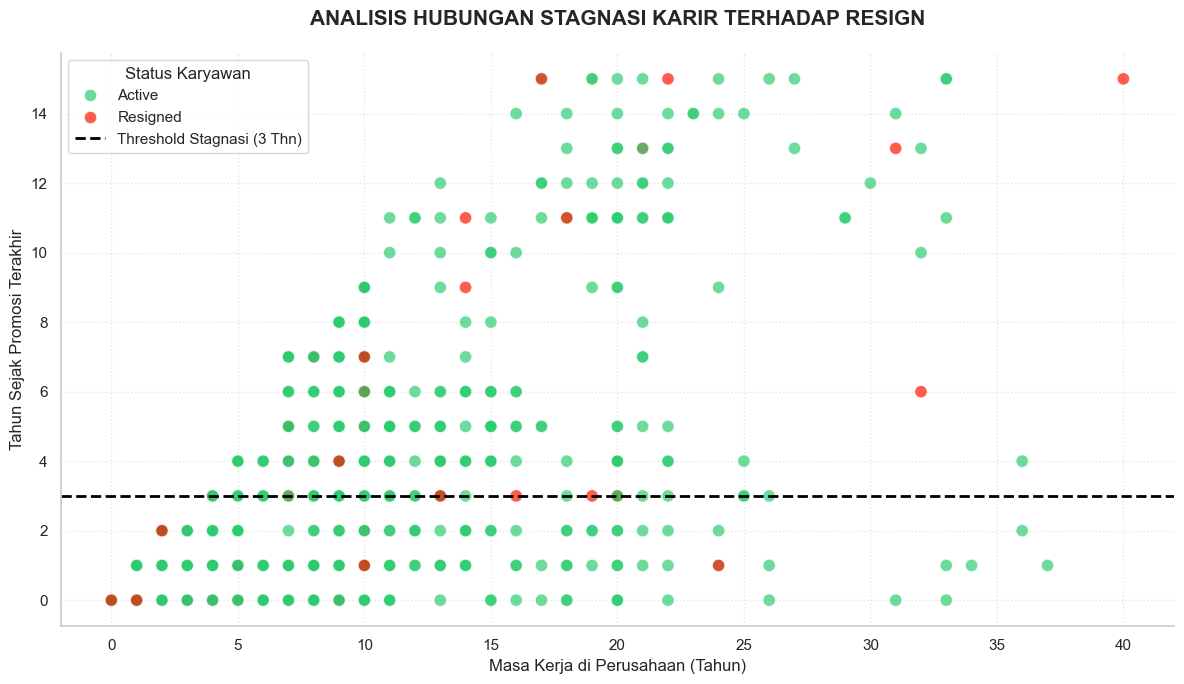


INTERPRETASI GRAFIK: STAGNASI KARIR VS ATTRITION

1. PENJELASAN VISUAL:
   - Titik MERAH: Karyawan yang sudah keluar (Resigned).
   - Titik HIJAU: Karyawan yang masih bertahan (Active).
   - Garis Putus-putus: Batas kritis 3 tahun tanpa kenaikan jabatan.

2. TEMUAN KUNCI (INSIGHT):
   - Terlihat penumpukan titik MERAH di atas garis 3 tahun.
   - Ini menunjukkan bahwa karyawan yang tidak mendapatkan promosi dalam
     rentang 3-5 tahun memiliki kecenderungan jauh lebih tinggi untuk resign.
   - Karyawan dengan masa kerja (YearsAtCompany) yang lama tapi 'stuck' di
     posisi yang sama adalah target empuk bagi kompetitor.

3. REKOMENDASI STRATEGIS:
   - HR harus melakukan 'Career Review' bagi karyawan yang sudah melewati
     ambang batas 3 tahun tanpa promosi.
   - Jika promosi struktural tidak memungkinkan, berikan promosi horizontal
     atau penugasan baru agar karyawan tidak merasa jenuh/stagnan.
--------------------------------------------------------------------------------



In [10]:

plt.figure(figsize=(12, 7))

# Scatter plot untuk melihat sebaran karyawan yang resign vs aktif
sns.scatterplot(
    data=df, 
    x='YearsAtCompany', 
    y='YearsSinceLastPromotion', 
    hue='Attrition_Status', 
    palette={'Resigned': "#fd1900", 'Active': '#2ecc71'}, 
    alpha=0.7,
    edgecolor='w',
    s=80 # Memperbesar titik agar lebih jelas
)

# Menambahkan garis ambang batas stagnasi (3 tahun tanpa promosi)
plt.axhline(y=3, color='black', linestyle='--', linewidth=2, label='Threshold Stagnasi (3 Thn)')

# Estetika Grafik
plt.title("ANALISIS HUBUNGAN STAGNASI KARIR TERHADAP RESIGN", fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Masa Kerja di Perusahaan (Tahun)", fontsize=12)
plt.ylabel("Tahun Sejak Promosi Terakhir", fontsize=12)
plt.legend(title="Status Karyawan", loc='upper left')
plt.grid(axis='both', linestyle=':', alpha=0.5)

sns.despine()
plt.tight_layout()
plt.show()

# KESIMPULAN ANALISIS STAGNASI KARIR (VERSI FIX INDENT)
print("\n" + "="*50)
print("INTERPRETASI GRAFIK: STAGNASI KARIR VS ATTRITION")
print("="*50)

print("\n1. PENJELASAN VISUAL:")
print("   - Titik MERAH: Karyawan yang sudah keluar (Resigned).")
print("   - Titik HIJAU: Karyawan yang masih bertahan (Active).")
print("   - Garis Putus-putus: Batas kritis 3 tahun tanpa kenaikan jabatan.")

print("\n2. TEMUAN KUNCI (INSIGHT):")
print("   - Terlihat penumpukan titik MERAH di atas garis 3 tahun.")
print("   - Ini menunjukkan bahwa karyawan yang tidak mendapatkan promosi dalam")
print("     rentang 3-5 tahun memiliki kecenderungan jauh lebih tinggi untuk resign.")
print("   - Karyawan dengan masa kerja (YearsAtCompany) yang lama tapi 'stuck' di")
print("     posisi yang sama adalah target empuk bagi kompetitor.")

print("\n3. REKOMENDASI STRATEGIS:")
print("   - HR harus melakukan 'Career Review' bagi karyawan yang sudah melewati")
print("     ambang batas 3 tahun tanpa promosi.")
print("   - Jika promosi struktural tidak memungkinkan, berikan promosi horizontal")
print("     atau penugasan baru agar karyawan tidak merasa jenuh/stagnan.")
print("-"*80 + "\n")

## 3. Data Preparation / Preprocessing

#### 3.1 Data Checking

In [11]:
df.head()

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition_Status
0,1,38,0.0,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,80,1,7,2,3,6,2,1,2,Active
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,80,0,15,2,1,1,0,0,0,Resigned
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,80,3,18,2,4,10,0,2,7,Resigned
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,80,1,23,2,4,20,4,4,8,Active
4,5,40,0.0,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,80,3,20,2,3,5,3,0,2,Active


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1470 non-null   float64
 3   BusinessTravel            1470 non-null   str    
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   str    
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   str    
 9   EmployeeCount             1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   str    
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   int64  
 14  JobLevel           

In [13]:
df.describe().round(4)

,EmployeeId,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.0000,1470.0000,1470.0000,1470.0000,1470.0000,1470.0000,1470.0,1470.0000,1470.0000,1470.0000,...,1470.0000,1470.0,1470.0000,1470.0000,1470.0000,1470.0000,1470.0000,1470.0000,1470.0000,1470.0000
mean,735.5000,36.9238,0.1218,802.4857,9.1925,2.9129,1.0,2.7218,65.8912,2.7299,...,2.7122,80.0,0.7939,11.2796,2.7993,2.7612,7.0082,4.2293,2.1878,4.1231
std,424.4968,9.1354,0.3271,403.5091,8.1069,1.0242,0.0,1.0931,20.3294,0.7116,...,1.0812,0.0,0.8521,7.7808,1.2893,0.7065,6.1265,3.6231,3.2224,3.5681
min,1.0000,18.0000,0.0000,102.0000,1.0000,1.0000,1.0,1.0000,30.0000,1.0000,...,1.0000,80.0,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000
25%,368.2500,30.0000,0.0000,465.0000,2.0000,2.0000,1.0,2.0000,48.0000,2.0000,...,2.0000,80.0,0.0000,6.0000,2.0000,2.0000,3.0000,2.0000,0.0000,2.0000
50%,735.5000,36.0000,0.0000,802.0000,7.0000,3.0000,1.0,3.0000,66.0000,3.0000,...,3.0000,80.0,1.0000,10.0000,3.0000,3.0000,5.0000,3.0000,1.0000,3.0000
75%,1102.7500,43.0000,0.0000,1157.0000,14.0000,4.0000,1.0,4.0000,83.7500,3.0000,...,4.0000,80.0,1.0000,15.0000,3.0000,3.0000,9.0000,7.0000,3.0000,7.0000
max,1470.0000,60.0000,1.0000,1499.0000,29.0000,5.0000,1.0,4.0000,100.0000,4.0000,...,4.0000,80.0,3.0000,40.0000,6.0000,4.0000,40.0000,18.0000,15.0000,17.0000


In [14]:
print(f"{'KOLOM':<25} | {'TIPE':<10} | {'UNIQUE':<8} | {'CONTOH DATA'}")
for col in df.columns:
    tipe = str(df[col].dtype)
    n_unique = df[col].nunique()
    contoh = list(df[col].unique()[:3]) # Ambil 3 contoh data
    
    print(f"{col:<25} | {tipe:<10} | {n_unique:<8} | {contoh}")
print(f"TOTAL: {df.shape[1]} Kolom | {df.shape[0]} Baris")

if df.isnull().sum().sum() > 0:
    print("\n[!] PERINGATAN: Ada data yang kosong!")
    print(df.isnull().sum()[df.isnull().sum() > 0])
else:
    print("\n DATA BERSIH: Tidak ada missing values.")


KOLOM                     | TIPE       | UNIQUE   | CONTOH DATA
EmployeeId                | int64      | 1470     | [np.int64(1), np.int64(2), np.int64(3)]
Age                       | int64      | 43       | [np.int64(38), np.int64(37), np.int64(51)]
Attrition                 | float64    | 2        | [np.float64(0.0), np.float64(1.0)]
BusinessTravel            | str        | 3        | ['Travel_Frequently', 'Travel_Rarely', 'Non-Travel']
DailyRate                 | int64      | 886      | [np.int64(1444), np.int64(1141), np.int64(1323)]
Department                | str        | 3        | ['Human Resources', 'Research & Development', 'Sales']
DistanceFromHome          | int64      | 29       | [np.int64(1), np.int64(11), np.int64(4)]
Education                 | int64      | 5        | [np.int64(4), np.int64(2), np.int64(3)]
EducationField            | str        | 6        | ['Other', 'Medical', 'Life Sciences']
EmployeeCount             | int64      | 1        | [np.int64(1)]
Environm

#### 3.2 Data Splitting

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Data berhasil dibagi! X_train dan y_train sekarang sudah siap dipakai.")

Data berhasil dibagi! X_train dan y_train sekarang sudah siap dipakai.


## 4. Modeling

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 1. SETUP MODEL ML
models = {
    'LR': LogisticRegression(class_weight='balanced', max_iter=10000),
    'SVM': SVC(class_weight='balanced', max_iter=10000),
    'DT': DecisionTreeClassifier(class_weight='balanced'),
    'GB': GradientBoostingClassifier(),
    'RF': RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42),
    'KNN': KNeighborsClassifier(),
    'NB': GaussianNB()
}
# 2. ADU MEKANIK MODEL & EVALUASI
print("="*60)
print(f"{'Model':<10} | {'Accuracy':<10}")
print("-"*60)

best_model_name = ""
best_accuracy = 0

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name:<10} | {acc:.2%}")
    
    if acc > best_accuracy:
        best_accuracy = acc
        best_model_name = name

print("-"*60)
print(f"MODEL TERBAIK: {best_model_name} ({best_accuracy:.2%})")
print("="*60)

# 3. ANALISIS FAKTOR & KESIMPULAN (VERSI EXCEL)
def analyze_attrition_factors_to_excel(X, y, best_name, best_acc):
    # Pakai RF sebagai standar pencarian fitur terpenting
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_model.fit(X, y)

    feat_importances = pd.DataFrame({
        'Faktor Penyebab': X.columns,
        'Skor Kepentingan': rf_model.feature_importances_
    }).nlargest(10, 'Skor Kepentingan')

    # Rapihin nama kolom
    feat_importances['Faktor Penyebab'] = feat_importances['Faktor Penyebab'].apply(
        lambda x: re.sub(r"(\w)([A-Z])", r"\1 \2", str(x))
    )

    # --- OUTPUT TABEL UNTUK EXCEL ---
    print(feat_importances.to_string(index=False))

    # --- KESIMPULAN NARASI ---
    top_factor = feat_importances.iloc[0]['Faktor Penyebab']
    
    print("\n" + "="*70)
    print("RINGKASAN EKSEKUTIF UNTUK MANAJEMEN")
    print("="*70)
    print(f"TEMUAN UTAMA: Faktor '{top_factor.upper()}' adalah pemicu resign nomor 1.")
    
    print("\nANALISIS:")
    print(f"1. Dari semua model yang diuji, {best_name} paling akurat ({best_acc:.2%}).")
    print(f"2. Faktor '{top_factor}' adalah variabel yang paling menentukan loyalitas.")
    print("3. Perusahaan perlu fokus pada 3 faktor teratas di tabel Excel.")

    print("\nREKOMENDASI ACTION PLAN:")
    if 'Income' in top_factor or 'Rate' in top_factor:
        print("-> Masalah Gaji: Segera lakukan audit kompensasi eksternal.")
    elif 'Over Time' in top_factor:
        print("-> Masalah Beban Kerja: Kurangi lembur, tambah personil tim.")
    elif 'Year' in top_factor or 'Promotion' in top_factor:
        print("-> Masalah Karir: Perbaiki struktur kenaikan jabatan internal.")
    else:
        print(f"-> Segera evaluasi kebijakan terkait {top_factor}.")
    print("="*70 + "\n")

analyze_attrition_factors_to_excel(X, y, best_model_name, best_accuracy)

Model      | Accuracy  
------------------------------------------------------------


c:\Users\adety.AdetyaTino\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 10000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LR         | 77.21%
SVM        | 48.64%
DT         | 84.35%
GB         | 88.44%
RF         | 87.76%
KNN        | 87.07%
NB         | 86.73%
------------------------------------------------------------
MODEL TERBAIK: GB (88.44%)
     Faktor Penyebab  Skor Kepentingan
                 Age          0.073344
      Monthly Income          0.069258
          Daily Rate          0.061056
        Monthly Rate          0.055241
         Hourly Rate          0.052738
 Total Working Years          0.050497
  Distance From Home          0.049127
           Over Time          0.044226
Num Companies Worked          0.037708
    Years At Company          0.036911

RINGKASAN EKSEKUTIF UNTUK MANAJEMEN
TEMUAN UTAMA: Faktor 'AGE' adalah pemicu resign nomor 1.

ANALISIS:
1. Dari semua model yang diuji, GB paling akurat (88.44%).
2. Faktor 'Age' adalah variabel yang paling menentukan loyalitas.
3. Perusahaan perlu fokus pada 3 faktor teratas di tabel Excel.

REKOMENDASI ACTION PLAN:
-> Segera evaluasi kebi

## 5. Evaluation

Fitting 3 folds for each of 96 candidates, totalling 288 fits

[ EVALUATION REPORT: TRAINING DATA BEST MODEL ]
------------------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.92      1.00      0.96      1033
         1.0       0.98      0.41      0.57       143

    accuracy                           0.93      1176
   macro avg       0.95      0.70      0.77      1176
weighted avg       0.93      0.93      0.91      1176



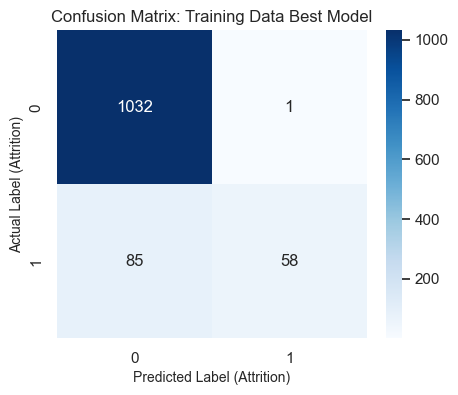


[ EVALUATION REPORT: TESTING DATA BEST MODEL ]
------------------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.89      0.98      0.93       258
         1.0       0.50      0.14      0.22        36

    accuracy                           0.88       294
   macro avg       0.70      0.56      0.58       294
weighted avg       0.84      0.88      0.85       294



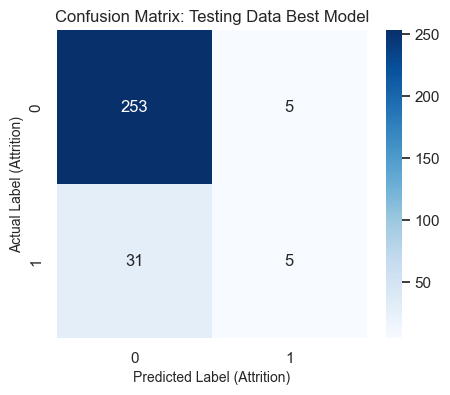

KESIMPULAN EVALUASI MODEL (INSIGHT UNTUK LAPORAN)
1. PERFORMA MODEL:
   - Akurasi Training : 92.69%
   - Akurasi Testing  : 87.76%

2. ANALISIS OVERFITTING:
     AMAN... : Model memiliki kemampuan generalisasi yang baik (Akurasi Train & Test stabil).

3. INTERPRETASI CONFUSION MATRIX:
   - Lihat kotak diagonal (Kiri-Atas & Kanan-Bawah): Itu adalah jumlah tebakan BENAR.
   - Lihat kotak False Negative (Kiri-Bawah): Ini adalah karyawan yang aslinya RESIGN
   - tapi diprediksi STAY. Ini adalah risiko kecolongan bagi HR.

4. REKOMENDASI:
   - Gunakan 'Best Estimator' hasil tuning ini untuk prediksi real-time karyawan aktif.
   - Fokus pada nilai RECALL untuk kelas 'Resigned' agar tidak ada karyawan potensial keluar yang luput dari pantauan.
   - Pertimbangkan penggunaan teknik regularisasi atau pengurangan kompleksitas model untuk mengurangi risiko overfitting.
----------------------------------------------------------------------------------------------------------------------------------

In [17]:

# EVALUATION REPORT MODEL FUNCTION
def evaluation_report(y_true, y_predicted, title='Data'):
    print(f'\n[ EVALUATION REPORT: {title.upper()} ]')
    print("-" * 60)
    print(classification_report(y_true, y_predicted))

    plt.figure(figsize=(5, 4))
    sns.heatmap(confusion_matrix(y_true, y_predicted), annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix: ' + title)
    plt.ylabel('Actual Label (Attrition)', fontsize=10)
    plt.xlabel('Predicted Label (Attrition)', fontsize=10)
    plt.show()


# HYPERPARAMETER TUNING (MENCARI SETTINGAN TERBAIK)
param_grid = {
    'loss': ['log_loss', 'exponential'],
    'learning_rate': [0.1, 0.01],
    'n_estimators': [100, 200], # Dikurangi dikit biar gak kelamaan nunggu
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
clf = GridSearchCV(estimator=models['GB'], param_grid=param_grid, cv=3, n_jobs=-1, verbose=1)
best_model = clf.fit(X_train, y_train)

# Predict menggunakan model terbaik hasil tuning
y_train_best = best_model.predict(X_train)
y_test_best = best_model.predict(X_test)

# Tampilan Laporan
evaluation_report(y_train, y_train_best, title='Training Data Best Model')
evaluation_report(y_test, y_test_best, title='Testing Data Best Model')

# ANALISIS & KESIMPULAN EVALUASI
print("KESIMPULAN EVALUASI MODEL (INSIGHT UNTUK LAPORAN)")
# Menghitung akurasi manual untuk narasi
from sklearn.metrics import accuracy_score
acc_train = accuracy_score(y_train, y_train_best)
acc_test = accuracy_score(y_test, y_test_best)

print(f"1. PERFORMA MODEL:")
print(f"   - Akurasi Training : {acc_train:.2%}")
print(f"   - Akurasi Testing  : {acc_test:.2%}")

print("\n2. ANALISIS OVERFITTING:")
if (acc_train - acc_test) > 0.10:
    print("     WARNING!: Model terdeteksi OVERFITTING. Model terlalu menghafal data latihan.")
else:
    print("     AMAN... : Model memiliki kemampuan generalisasi yang baik (Akurasi Train & Test stabil).")

print("\n3. INTERPRETASI CONFUSION MATRIX:")
print("   - Lihat kotak diagonal (Kiri-Atas & Kanan-Bawah): Itu adalah jumlah tebakan BENAR.")
print("   - Lihat kotak False Negative (Kiri-Bawah): Ini adalah karyawan yang aslinya RESIGN")
print("   - tapi diprediksi STAY. Ini adalah risiko kecolongan bagi HR.")


print("\n4. REKOMENDASI:")
print("   - Gunakan 'Best Estimator' hasil tuning ini untuk prediksi real-time karyawan aktif.")
print("   - Fokus pada nilai RECALL untuk kelas 'Resigned' agar tidak ada karyawan potensial keluar yang luput dari pantauan.")
print("   - Pertimbangkan penggunaan teknik regularisasi atau pengurangan kompleksitas model untuk mengurangi risiko overfitting.")
print("-"*130 + "\n")

####     MODEL EXPORT and PROJECT REQUIREMENTS

In [18]:
output_dir = 'deployment_assets'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    
# 1. Simpan Model ke dalam folder khusus
model_path = os.path.join(output_dir, 'model_gb.joblib')
joblib.dump(best_model, model_path)

# 2. Bikin daftar library (requirements.txt) buat Streamlit nanti
!pip freeze > requirements.txt

print(f" Model berhasil disimpan sebagai: {model_path}")
print(f" File requirements.txt berhasil dibuat.")

 Model berhasil disimpan sebagai: deployment_assets\model_gb.joblib
 File requirements.txt berhasil dibuat.
